In [2]:
import numpy as np
import pandas as pd
import scanpy as sc

from plotnine import *
sc.set_figure_params(figsize = (5,5))

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/setuptools_scm/_integration/setuptools.py:31: RuntimeWarning: 
ERROR: setuptools==58.1.0 is used in combination with setuptools_scm>=8.x

Your build configuration is incomplete and previously worked by accident!
setuptools_scm requires setuptools>=61

Suggested workaround if applicable:
 - migrating from the deprecated setup_requires mechanism to pep517/518
   and using a pyproject.toml to declare build dependencies
   which are reliably pre-installed before running the build tools

  warnings.warn(


In [3]:
satpathy = sc.read_h5ad("anndatas/current_satpathy.h5ad")
satpathy

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


AnnData object with n_obs × n_vars = 27603 × 181269
    obs: 'n_genes_by_counts', 'total_counts', 'high_counts', 'sample', 'leiden', 'annotation', 'Miller_cd8_dys_d20_term_vs_cd8_dys_d20_prog', 'Miller_cd8_dys_d20_prog_vs_cd8_dys_d20_term', 'Miller_cd8_dys_lcmv_d30_term_vs_cd8_dys_lcmv_d30_prog', 'Miller_cd8_dys_lcmv_d30_prog_vs_cd8_dys_lcmv_d30_term', 'Chen_cd8_naive_vs_cd8_dys_melanoma_progenitor', 'Chen_cd8_dys_melanoma_progenitor_vs_cd8_naive', 'Miller_cd8_dys_d20_term_vs_cd8_dys_lcmv_d30_prog', 'Miller_cd8_dys_lcmv_d30_prog_vs_cd8_dys_d20_term', 'Miller_cd8_dys_d20_prog_vs_cd8_dys_lcmv_d30_term', 'Miller_cd8_dys_lcmv_d30_term_vs_cd8_dys_d20_prog', 'Chen_cd8_dys_melanoma_progenitor_vs_cd8_dys_melanoma', 'Chen_cd8_dys_melanoma_vs_cd8_dys_melanoma_progenitor', 'Miller_cd8_dys_d20_prog_vs_cd8_dys_lcmv_d30_prog', 'Miller_cd8_dys_lcmv_d30_prog_vs_cd8_dys_d20_prog', 'new progenitor score', 'Cd8 naive arch', 'Cd8 mem arch', 'Cd4 Tfh arch', 'Cd8 dys arch', 'T cell activation arch', 'Cd8 ef

In [4]:
satpathy.obsm["X_umap"] = satpathy.obsm["X_umap_theirs"].copy()

In [5]:
satpathy.uns["leiden_colors"] = ["#7BD389", "#234057", "#D1234C","#EACCB6",   "#abbadf"]

In [6]:
sc.settings.figdir = "fig2_plots"

## panel A

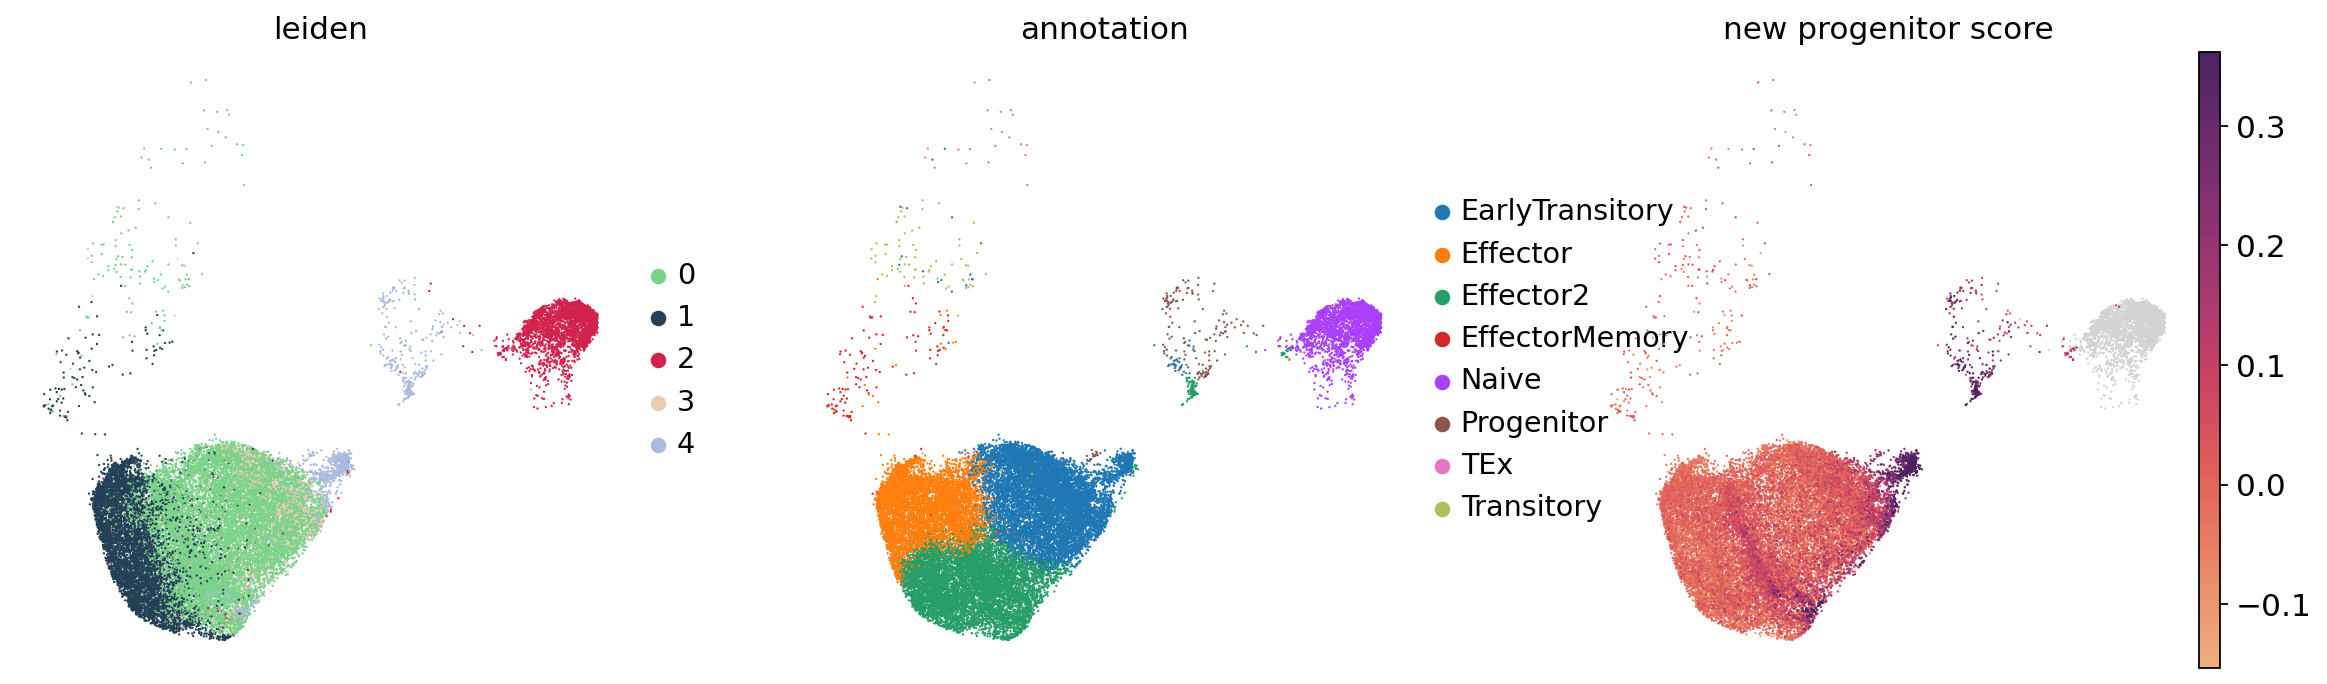

In [9]:
import seaborn as sns ## for flare
sc.pl.umap(satpathy, color = ["leiden","annotation", "new progenitor score"], vmin = "p1", vmax = "p99", cmap = "flare",
          frameon = False, ncols = 3, save = "_supp_sat.pdf")

In [10]:
satpathy.obs.loc[(satpathy.obs["leiden"] == "4") & (satpathy.obs["annotation"] == "Progenitor"), "prog status"
                ]  = "prog in both"
satpathy.obs.loc[(satpathy.obs["leiden"] == "4") & (satpathy.obs["annotation"] != "Progenitor"), "prog status"
                ]  = "prog in mine"
satpathy.obs.loc[(satpathy.obs["leiden"] != "4") & (satpathy.obs["annotation"] == "Progenitor"), "prog status"
                ]  = "prog in theirs"

## panel B

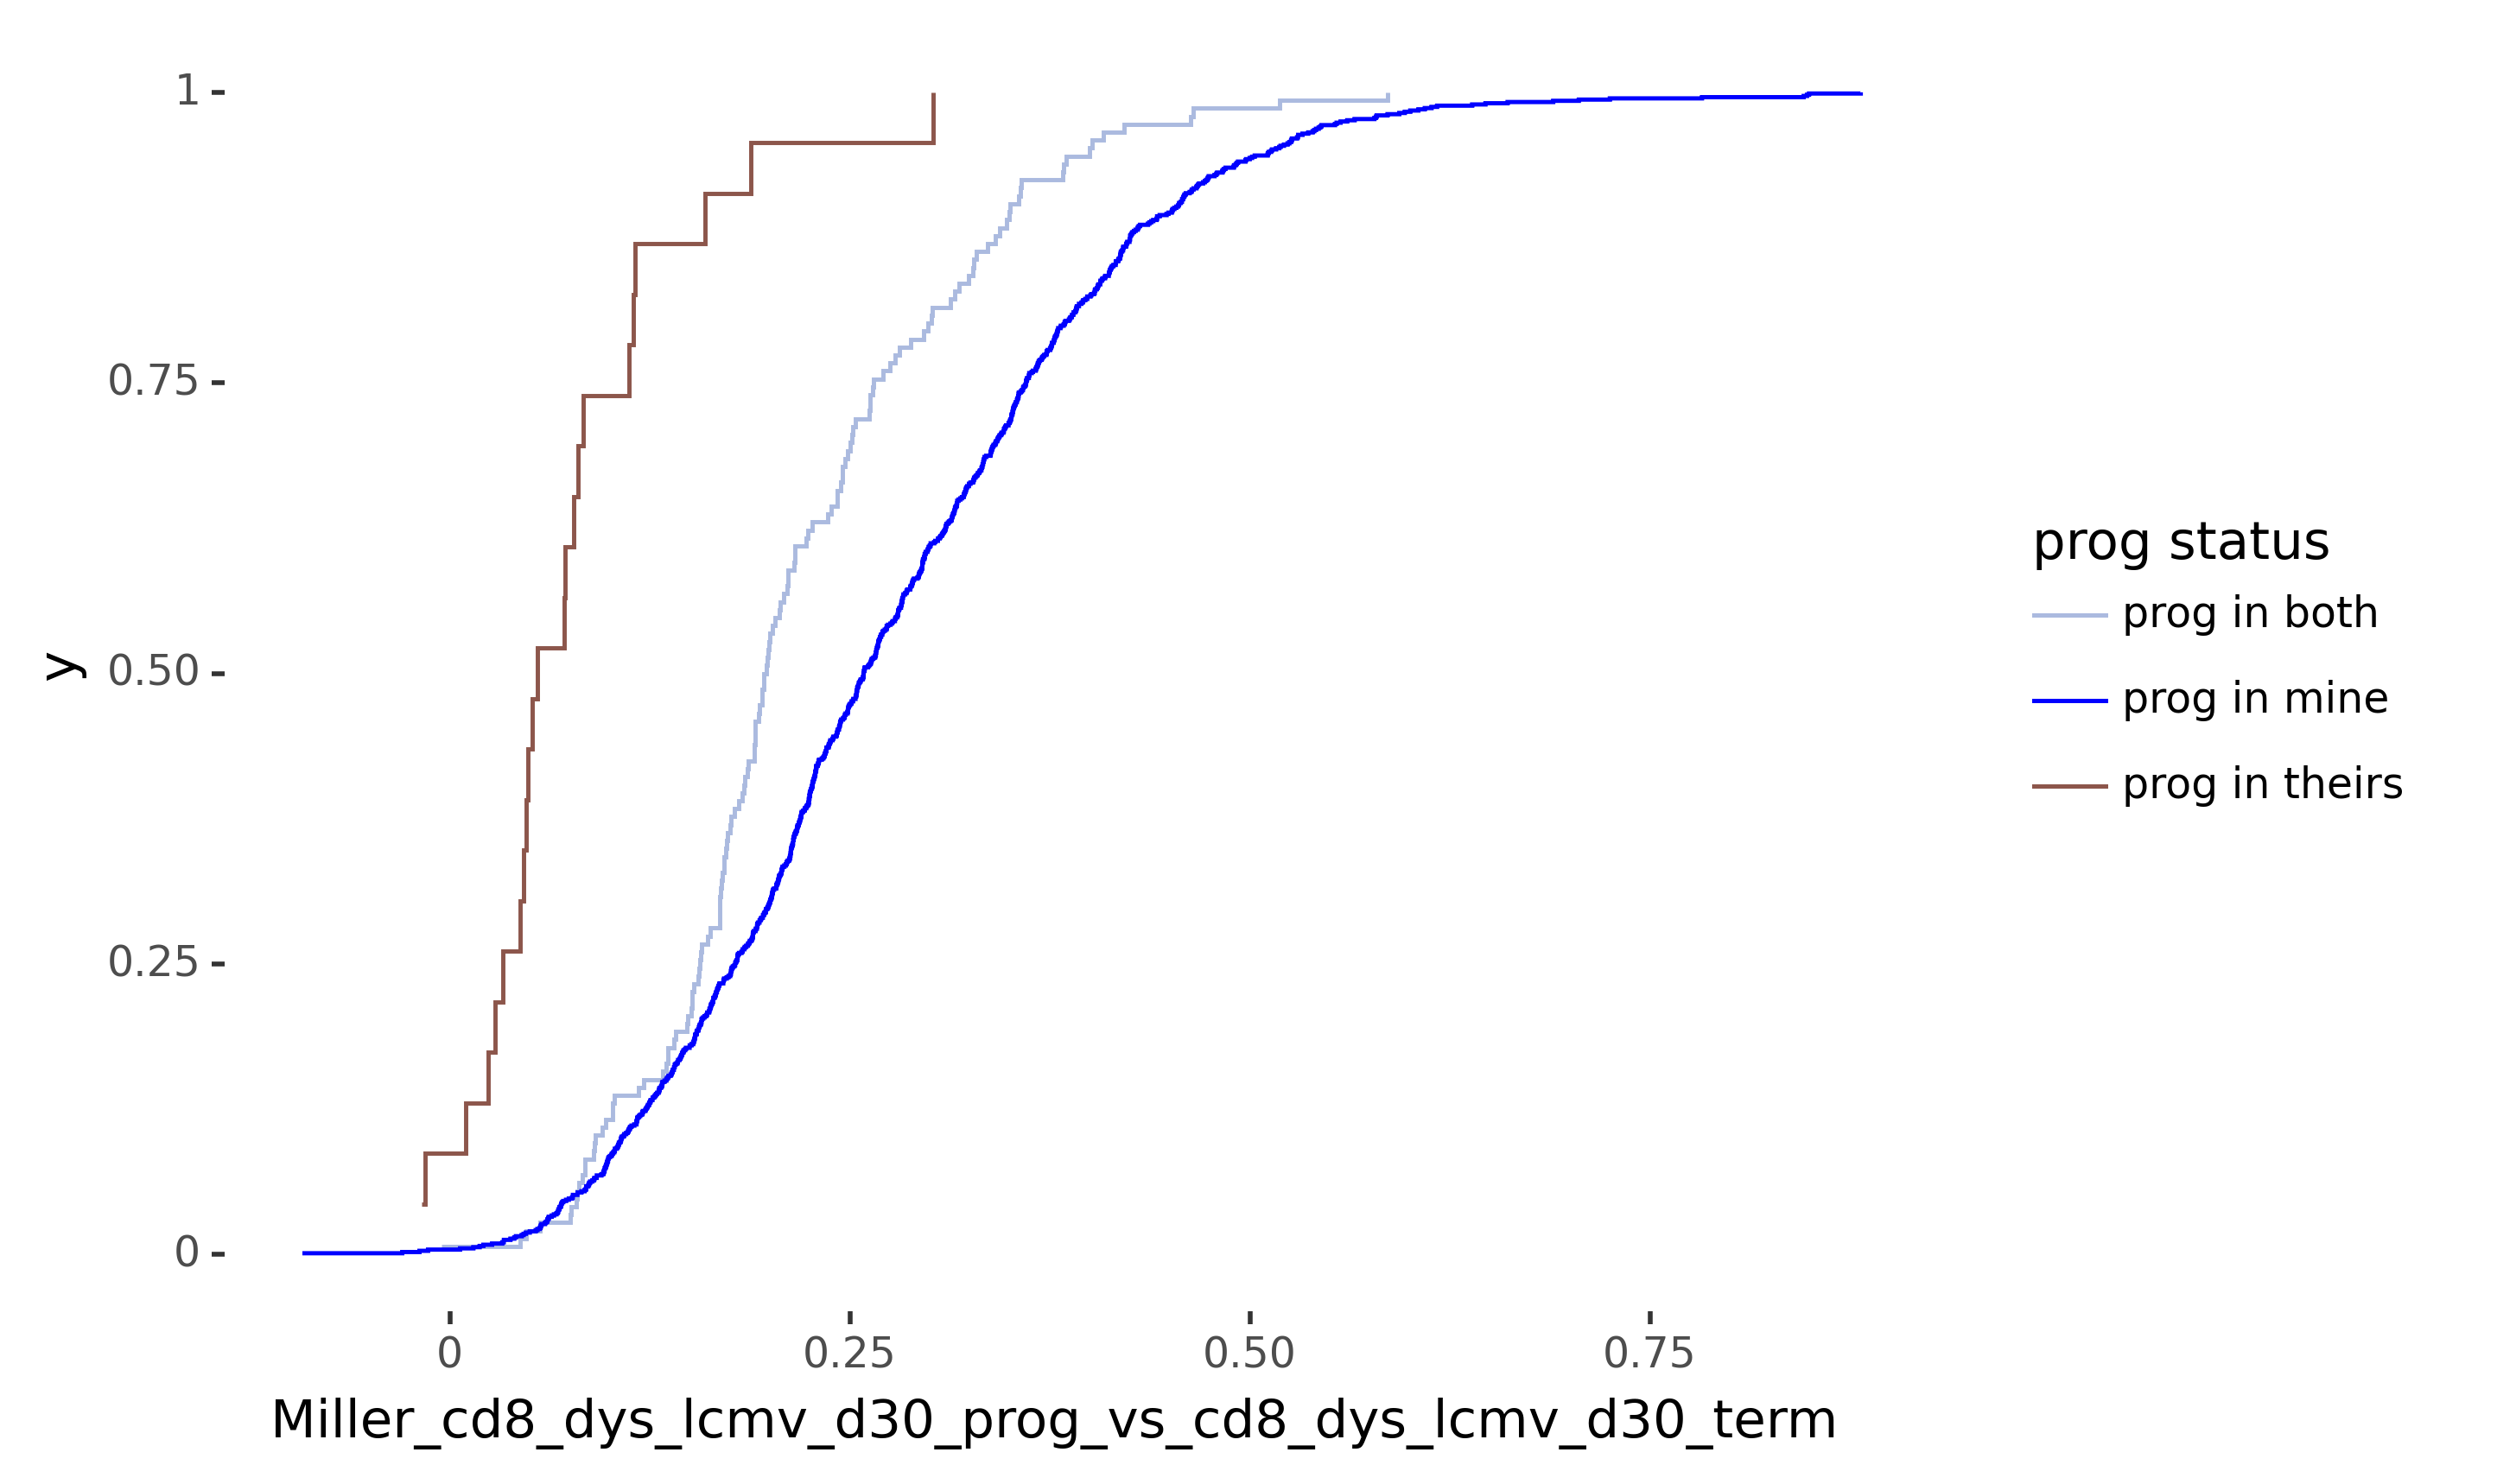

<ggplot: (8761679880783)>

In [11]:
sat_prog = ggplot(satpathy.obs.dropna(), aes(x = "Miller_cd8_dys_lcmv_d30_prog_vs_cd8_dys_lcmv_d30_term", color = 
                                             "prog status")) + stat_ecdf() + theme_tufte() + scale_color_manual({
    "prog in both": "#abbadf", "prog in theirs": "#8c564b", "prog in mine": "blue"}) + theme(dpi = 200) 
sat_prog

In [137]:
ggsave(sat_prog, "fig2_plots/supp_prog_cdf_sat.pdf", dpi = 300)

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: fig2_plots/supp_prog_cdf_sat.pdf


## compare distances for cells in different clusters

In [12]:
def test_annot(a, annot_string = "annotation"):
    print(a)
    n_cells = np.sum(satpathy.obs[annot_string] == a)
    test_n = [satpathy[satpathy.obs[annot_string] == a].obsp["distances"][i, :].nnz for i in range(n_cells)]
    return {"annot": a, "distances": np.array(satpathy[satpathy.obs[annot_string] == a].obsp["distances"].mean(
        1)).flatten(), "n neighbors": test_n}

testing_annotation_distances = pd.concat([pd.concat([pd.DataFrame(test_annot(a)) for a in satpathy.obs[
    "annotation"].unique()]).assign(version = "theirs"), pd.concat([pd.DataFrame(test_annot(
    a, "leiden")) for a in satpathy.obs["leiden"].unique()]).assign(version = "mine")])

Effector2
EarlyTransitory
Naive
Effector
Transitory
Progenitor
EffectorMemory
TEx
1
0
3
2
4


In [13]:
colors = { a: satpathy.uns["annotation_colors"][i] for i, a in enumerate(satpathy.obs.sort_values("annotation")[
    "annotation"].unique())}
for i, a in enumerate(satpathy.obs.sort_values("leiden")["leiden"].unique()):
    colors[a] = satpathy.uns["leiden_colors"][i] 

## panel C

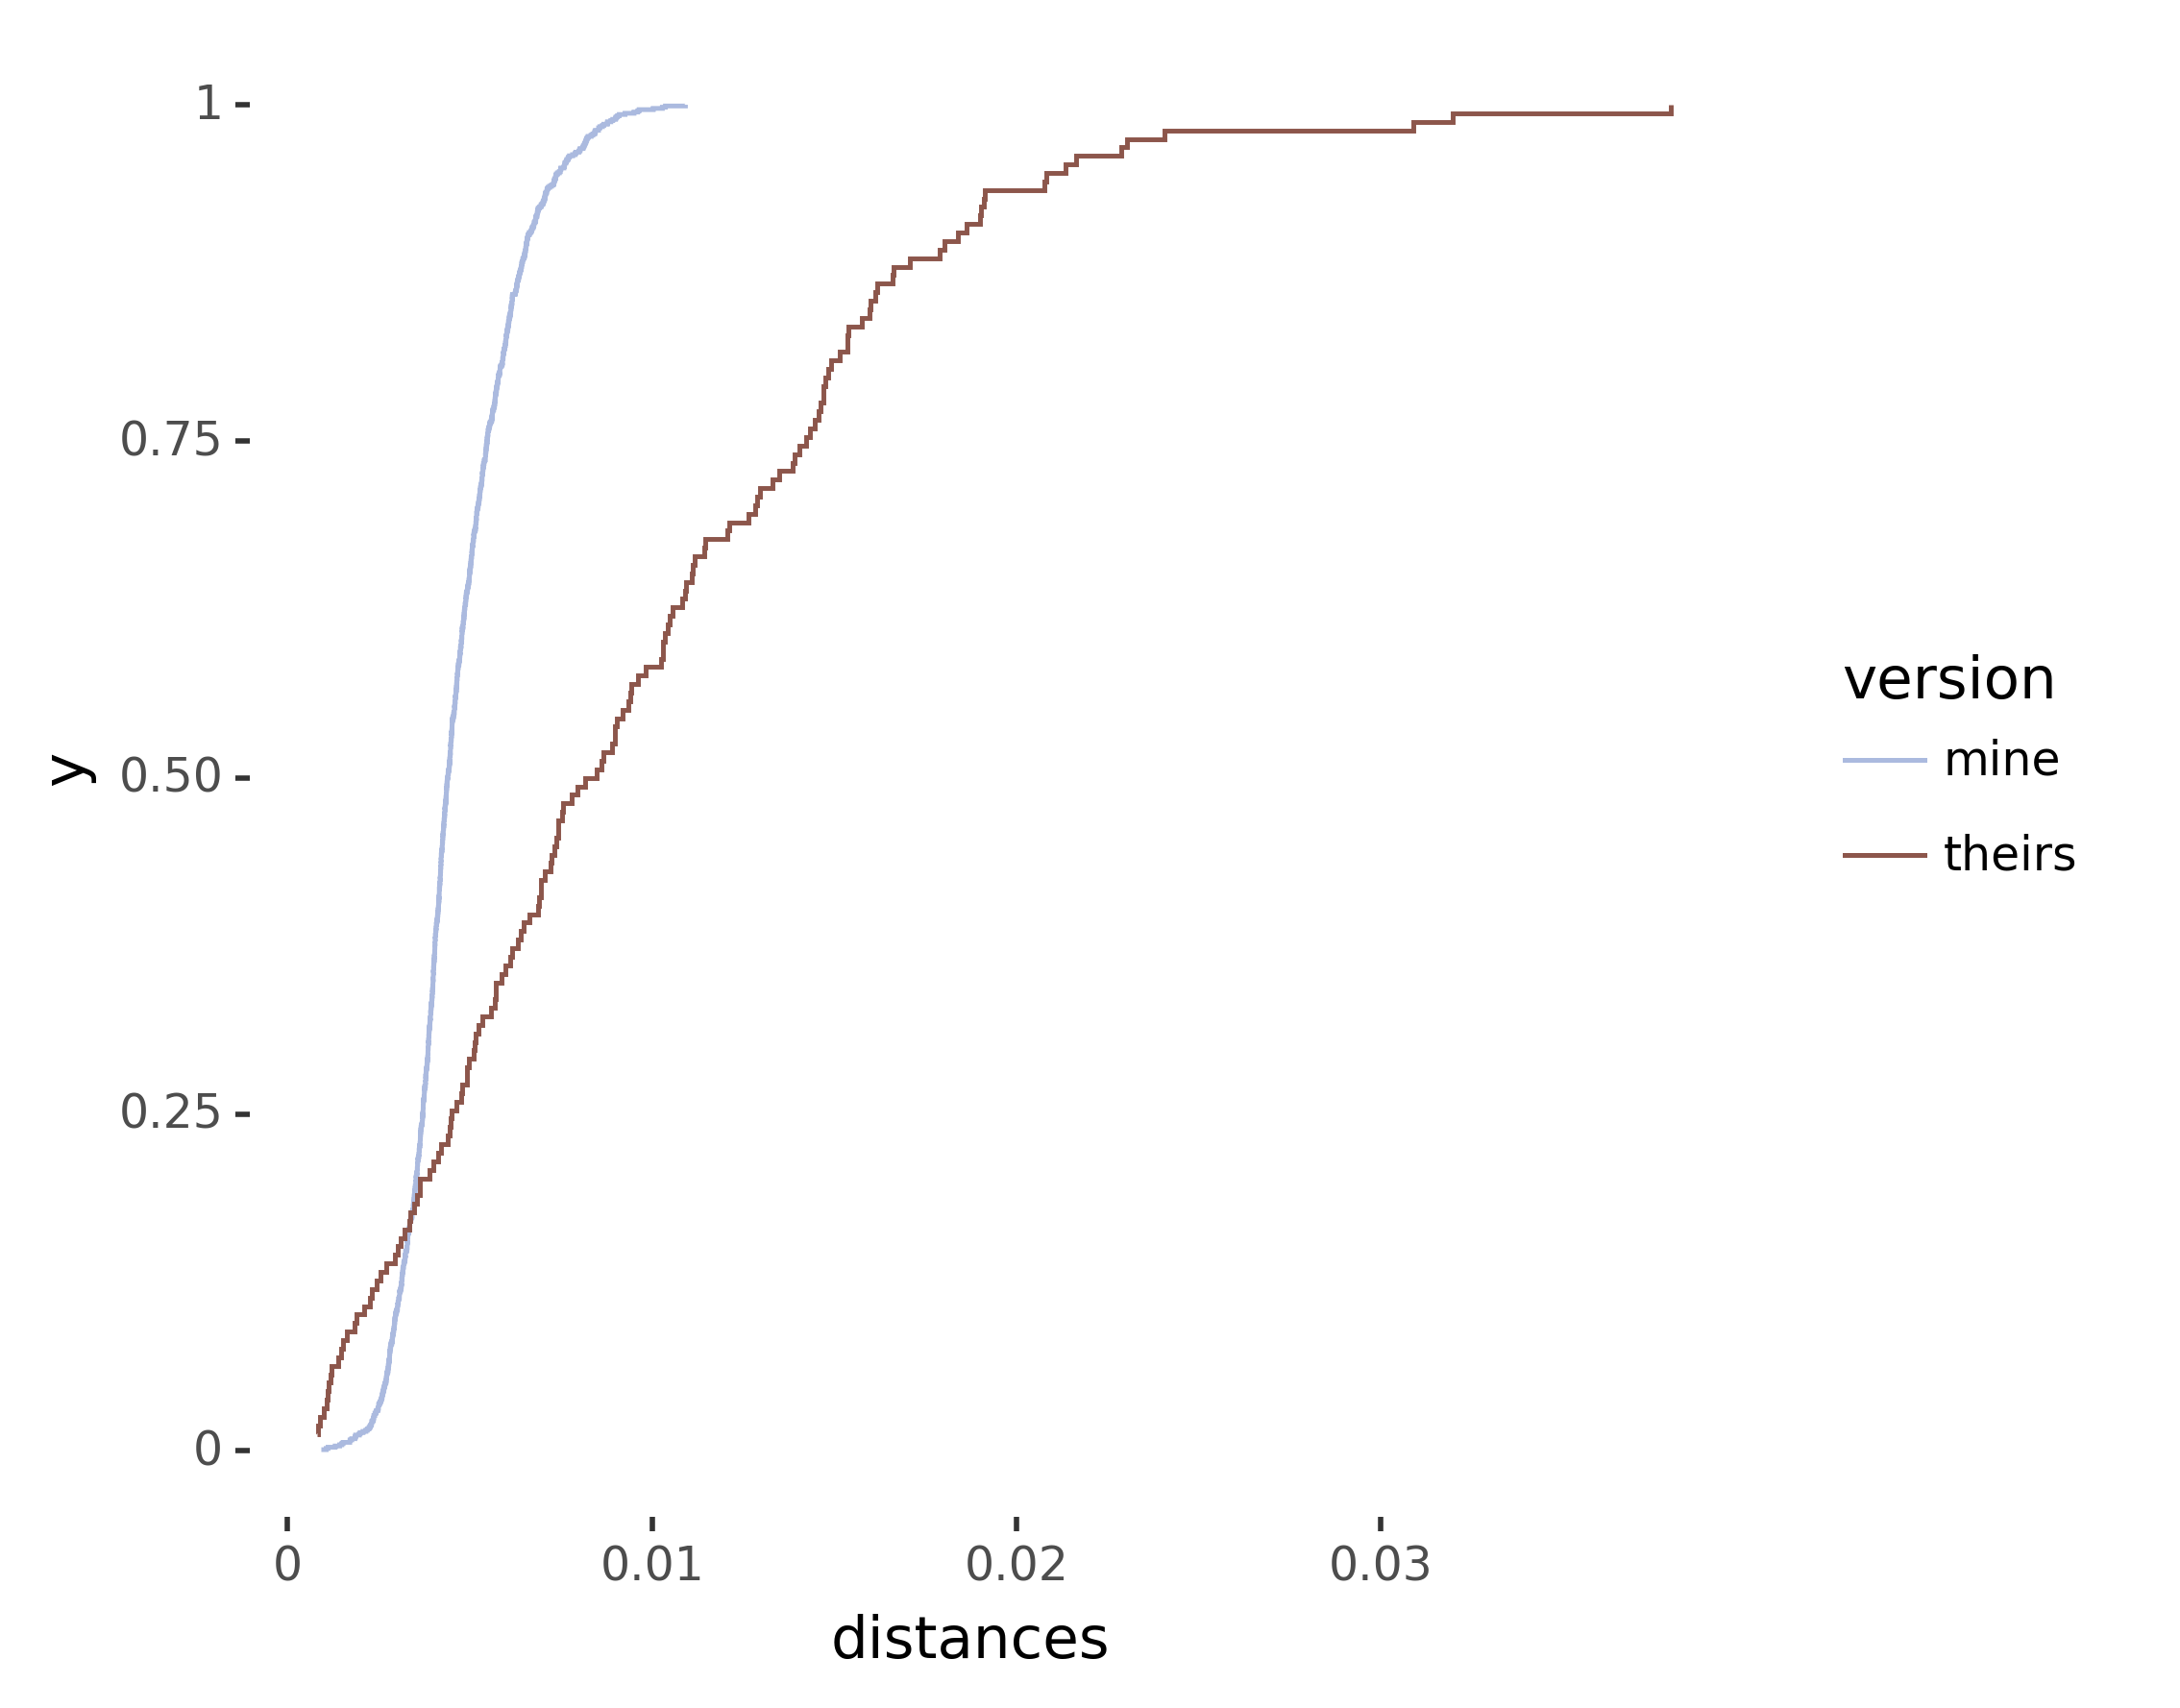

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 5 x 5 in image.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: fig2_plots/supp_prog_neighbors_cdf_sat.pdf


In [14]:
plt_c = ggplot(testing_annotation_distances[(testing_annotation_distances["annot"].isin(["Progenitor", "4"])) & (
    testing_annotation_distances["n neighbors"] > 0)], aes(x="distances", color = "version")) + stat_ecdf() + \
theme_tufte() + theme(dpi = 200, figure_size = (5, 5)) + scale_color_manual({
    "theirs": '#8c564b', "mine": "#abbadf"}) 
print(plt_c)
ggsave(plt_c, "fig2_plots/supp_prog_neighbors_cdf_sat.pdf")
# + stat_ecdf(aes(
#    x="distances", linetype = "version"), color = "#bababa", data = testing_annotation_distances[(
#    ~testing_annotation_distances["annot"].isin(["Progenitor", "4"])) & (testing_annotation_distances[
#    "n neighbors"] > 0)])

In [16]:
from sklearn.metrics import silhouette_samples

In [20]:
satpathy.obsm

AxisArrays with keys: X_pca, X_umap, X_umap_mine, X_umap_theirs

In [21]:
annot_silhouettes = silhouette_samples(satpathy.obsm["X_umap_mine"], labels = satpathy.obs["annotation"], 
                                       metric = "cosine")

In [22]:
leiden_silhouettes = silhouette_samples(satpathy.obsm["X_umap_mine"], labels = satpathy.obs["leiden"], 
                                       metric = "cosine")

In [23]:
their_annot_silhouettes = silhouette_samples(satpathy.obsm["X_umap_theirs"], labels = satpathy.obs["annotation"],
                                             metric = "cosine")

In [24]:
their_leiden_silhouettes = silhouette_samples(satpathy.obsm["X_umap_theirs"], labels = satpathy.obs["leiden"],
                                        metric = "cosine")

In [46]:
silhouettes = pd.concat([pd.DataFrame({"silhouette": their_annot_silhouettes, "labeling": "annot", "version":
                                       "theirs", "cluster": satpathy.obs["annotation"]}), pd.DataFrame({
    "silhouette": their_leiden_silhouettes, "labeling": "leiden", "version": "theirs", "cluster": satpathy.obs[
        "annotation"]}), pd.DataFrame({"silhouette": annot_silhouettes, "labeling": "annot", "version": "mine",
                                       "cluster": satpathy.obs["leiden"]}), pd.DataFrame({
    "silhouette": leiden_silhouettes, "labeling": "leiden", "version": "mine", "cluster": satpathy.obs["leiden"]}
)])

In [47]:
silhouettes_v2 = silhouettes.reset_index().pivot_table(columns = "version", index = ["index", "labeling"],
                                                       values = "silhouette").reset_index()

## panel D

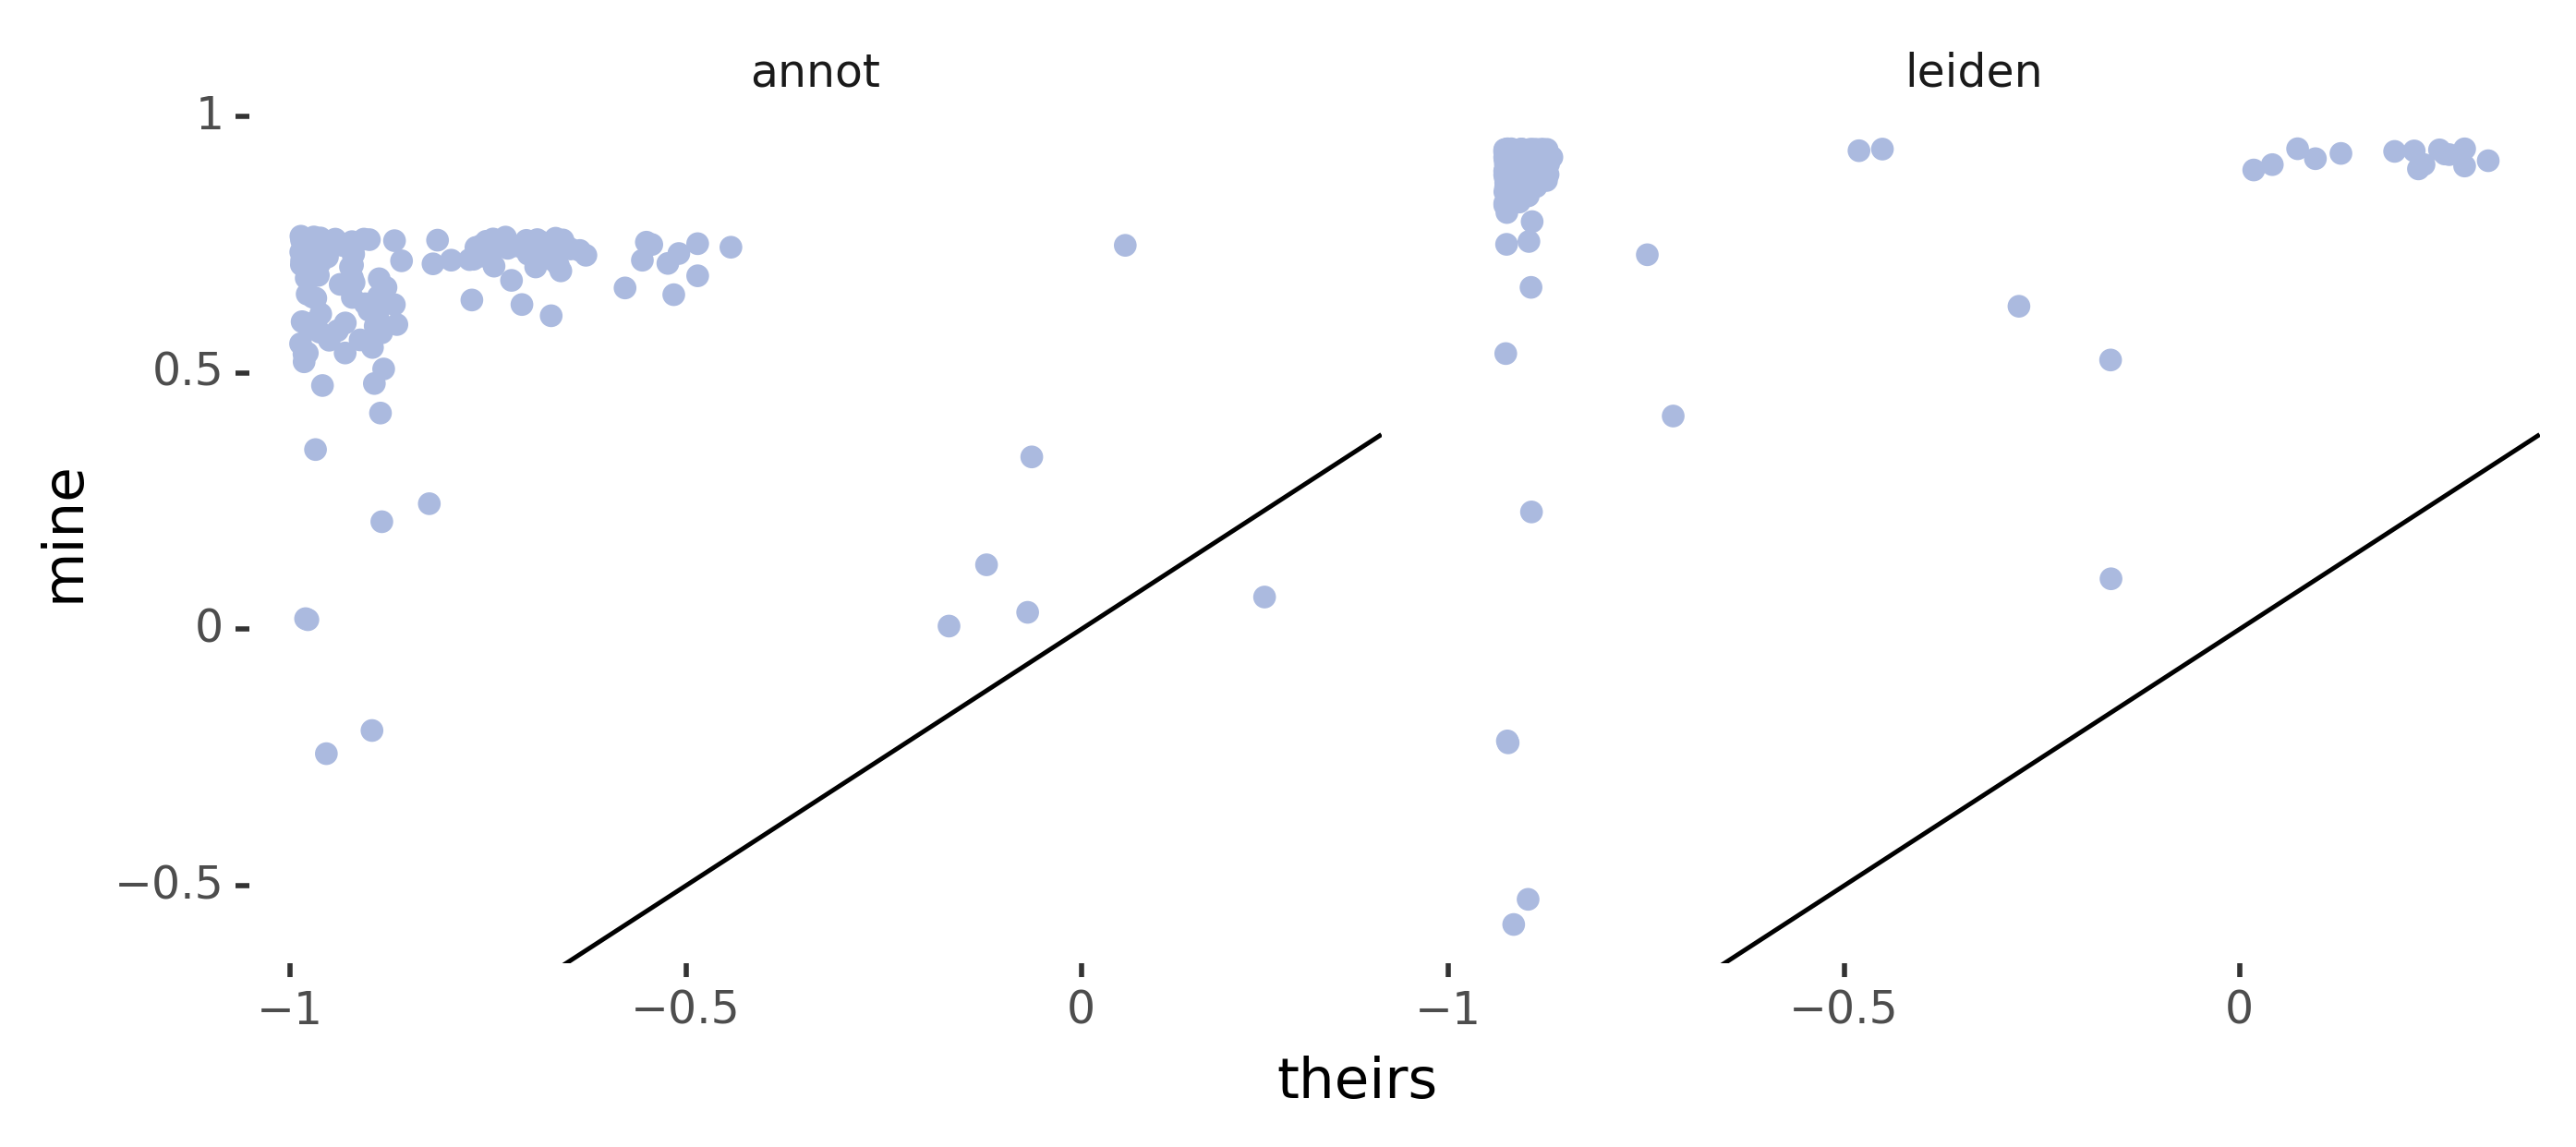

<ggplot: (8761669719546)>

In [48]:
sil_plt = ggplot(silhouettes_v2.set_index("index").loc[satpathy[(satpathy.obs["leiden"] == "4") & (satpathy.obs[
    "annotation"] == "Progenitor")].obs_names], aes(x="theirs", y = "mine")) + geom_point(
    color = colors["4"]) + theme_tufte() + theme(dpi = 200, figure_size = (8, 3)) + facet_wrap("~ labeling") + \
geom_abline(slope = 1, intercept = 0)
sil_plt

In [264]:
ggsave(sil_plt, "fig2_plots/supp_prog_silhouette.pdf", dpi = 200)

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 8 x 3 in image.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: fig2_plots/supp_prog_silhouette.pdf


## now look at archetype scores

,variable,value
0,Cd8 naive arch,0.134040
1,Cd8 naive arch,0.090360
2,Cd8 naive arch,0.113681
3,Cd8 naive arch,0.142888
4,Cd8 naive arch,0.183231
...,...,...
8851,Cd4 naive-mem arch,0.300571
8852,Cd4 naive-mem arch,0.166611
8853,Cd4 naive-mem arch,0.225638
8854,Cd4 naive-mem arch,0.122716


In [54]:
arch_colors = {"Cd8 naive arch": "#3E7958",
               "Cd8 mem arch": "#A4CCB4",
               "Cd4 Tfh arch": "#C4AF9A",
               "Cd8 dys arch": "#2B3A67",
               "Cd4 Th1 arch": "#D58696",
               "T cell activation arch": "#D58696",
               "Cd8 eff arch": "#73ACBF",
               "Cd4 Treg arch": "#FFDE70",
               "Cd4 naive-mem arch": "#C85919",
              "no arch": "#d0d0d0"}

## panel E

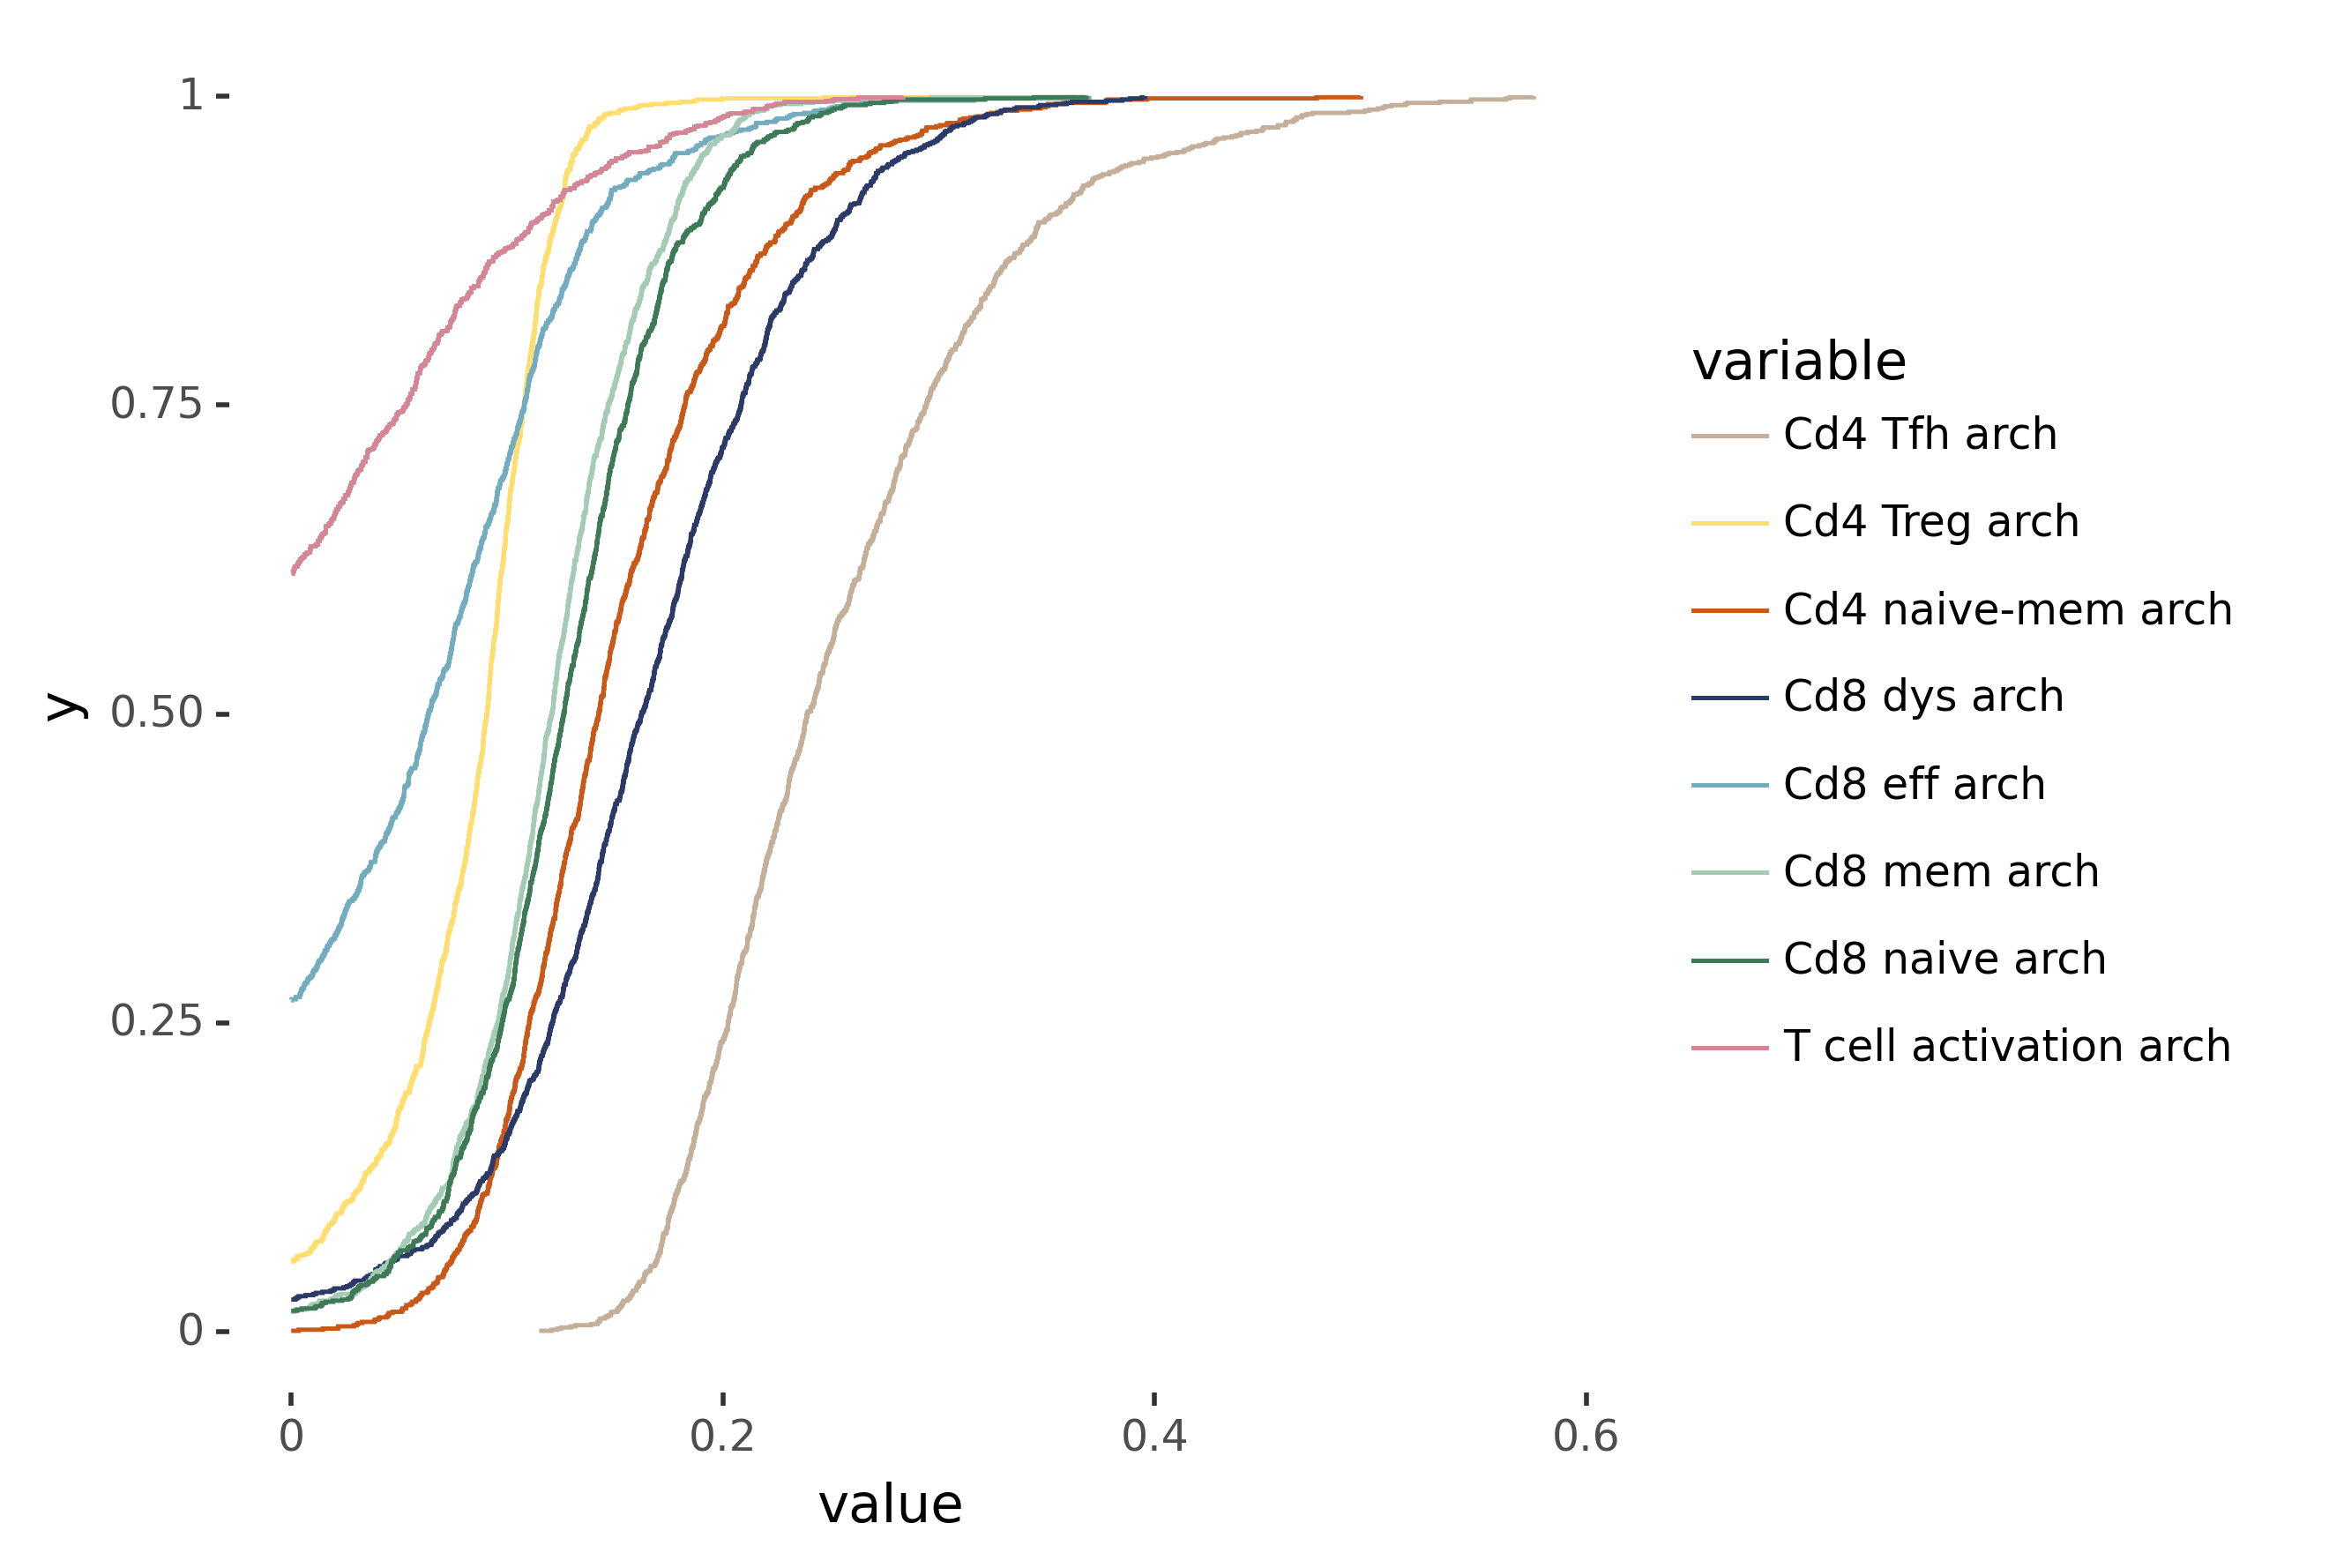

<ggplot: (8761669164282)>

In [56]:
sat_arch_scores = ggplot(satpathy.obs[satpathy.obs["leiden"] == "4"].melt(value_vars = satpathy.obs.columns[
    satpathy.obs.columns.str.endswith("arch")]), aes(x="value", color = "variable")) + stat_ecdf() + \
theme_tufte() + theme(dpi = 200, figure_size = (5, 5)) + scale_color_manual(arch_colors)
sat_arch_scores

In [40]:
ggsave(sat_arch_scores, "fig2_plots/supp_prog_cdf_sat_archs.pdf")

/Genomics/argo/users/skwalker/lipstic_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 5 x 5 in image.
/Genomics/argo/users/skwalker/lipstic_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: fig2_plots/supp_prog_cdf_sat_archs.pdf


## bottom half: Wherry dataset (Giles *et al*.)

In [5]:
wherry = sc.read_h5ad("anndatas/wherry_combined_dataset2.h5ad")

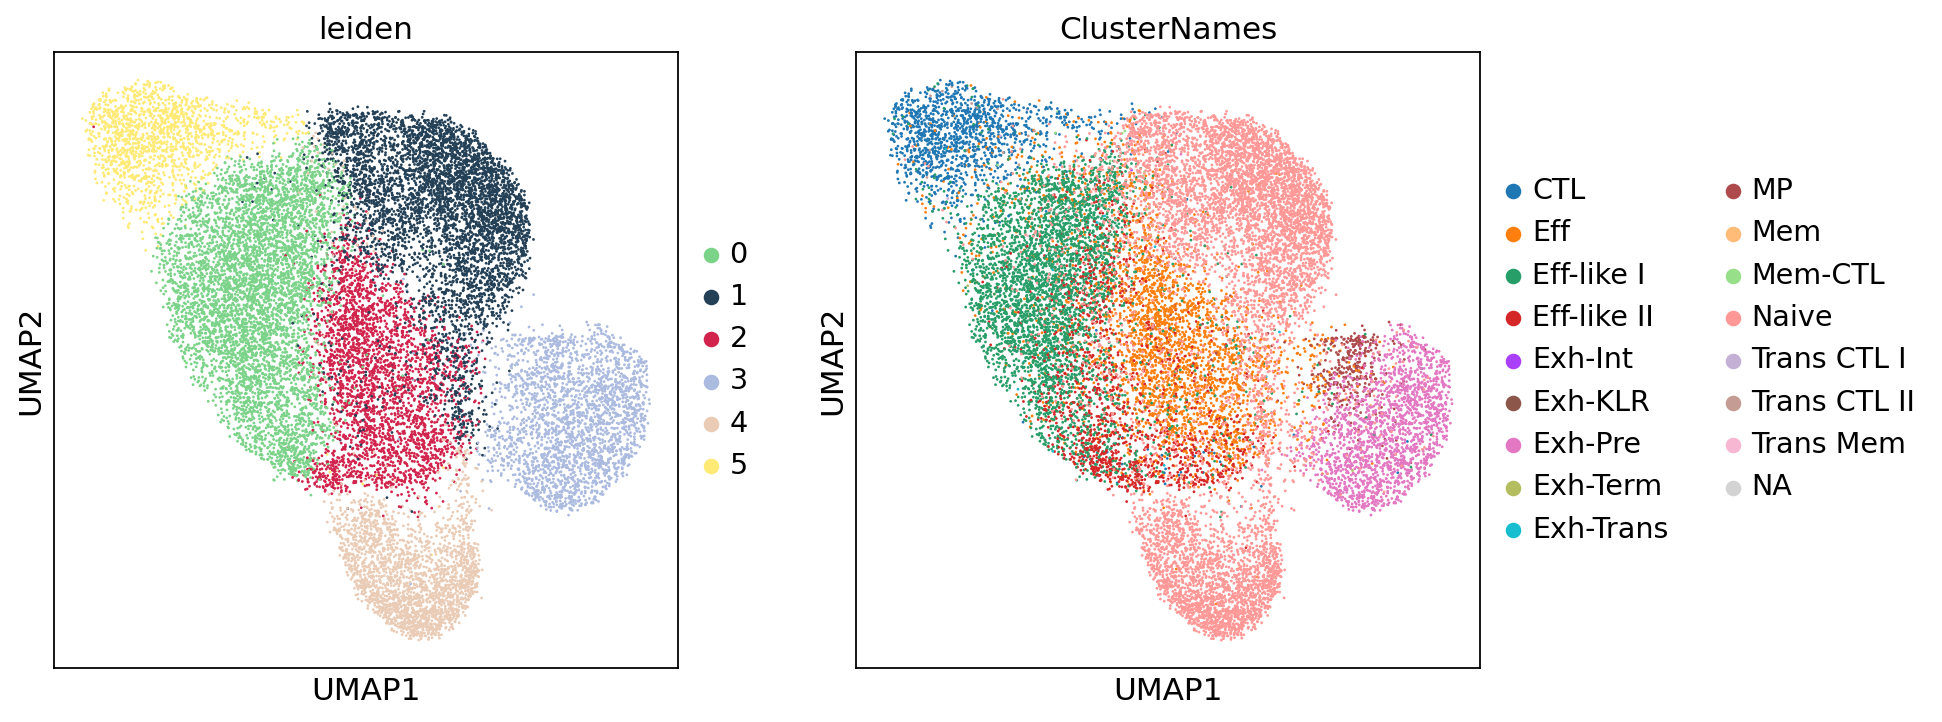

In [111]:
sc.pl.umap(wherry, color = ["leiden", "ClusterNames"])

In [112]:
wherry_pca = pd.read_csv("wherry_pca.csv", index_col=0)

In [113]:
wherry_pca

,AAACGAAAGACAGTGC-1.arm_d8,AAACGAAAGACGTCAG-1.arm_d8,AAACGAAAGACTAATG-1.arm_d8,AAACGAAAGATCACCT-1.arm_d8,AAACGAAAGCGTGTTT-1.arm_d8,AAACGAACAATGGCTT-1.arm_d8,AAACGAACATAGATAG-1.arm_d8,AAACGAACATGGTATC-1.arm_d8,AAACGAACATTTGGTG-1.arm_d8,AAACGAAGTCAACTGT-1.arm_d8,...,TTTGTGTCAAGGTTCT-1.naive,TTTGTGTCAGGATAGC-1.naive,TTTGTGTCATACAACC-1.naive,TTTGTGTGTAAGGTCG-1.naive,TTTGTGTGTGGAAAGA-1.naive,TTTGTGTGTGTCGTGC-1.naive,TTTGTGTGTTCCAATG-1.naive,TTTGTGTTCCTCCAGT-1.naive,TTTGTGTTCGCACAAT-1.naive,TTTGTGTTCGTGAGTT-1.naive
0,-6.298305,21.161032,-1.612305,2.339035,-12.960093,-4.922719,-7.082408,-8.501520,-1.999272,-12.467802,...,3.282631,-4.342164,3.105344,-1.498737,3.235388,6.339172,-1.473541,-1.532967,0.532939,-0.325189
1,-1.381358,8.231305,-4.356540,9.722840,-4.896781,-0.249178,4.050457,3.919900,4.244924,-1.024639,...,2.430392,-3.392971,4.175419,-4.044153,4.066677,10.652751,-6.508444,-0.620036,4.333939,2.633920
2,-0.568572,-10.651689,1.928543,-7.926832,3.435889,-2.596787,-1.132421,-0.918514,-2.440543,-0.028266,...,-2.596755,2.721756,-1.356849,1.175666,-2.400994,-3.574113,3.790678,-0.038816,-1.200818,-4.923509
3,-4.931247,-8.560812,-9.111682,-1.638955,-2.558785,-8.063773,-6.798929,-3.625458,-6.756947,1.994862,...,-3.185942,2.652703,-0.866249,-2.984637,-3.472950,1.630959,-2.236704,1.263516,0.926173,-12.112739
4,4.998637,4.404186,7.954761,-5.539535,4.309017,9.246684,5.514370,-4.573487,9.596447,-7.148349,...,-2.093729,-1.878566,-0.993379,1.674146,0.471696,-5.121990,1.918793,-2.464644,-5.235849,5.579811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3.278340,2.208280,-2.202421,1.407047,1.940926,3.301448,0.899879,-1.348020,4.449353,-1.140604,...,1.718144,-1.000886,1.546029,-1.555825,-3.052075,0.781550,-0.588054,0.892924,0.361320,1.793398
96,1.051038,-0.020352,-1.788901,-0.354550,1.005810,1.767587,-1.381203,0.280529,1.723810,1.076437,...,-1.625042,-0.388553,-0.998849,-0.614236,3.002897,0.682782,-2.483274,2.910184,0.180402,-1.755035
97,1.541872,-6.700364,0.041737,-3.576825,6.935506,-2.731740,1.711744,2.904337,2.445458,2.601349,...,2.299917,-0.700933,0.958300,-1.058453,-1.669329,-2.615464,0.786595,0.948452,-0.554696,-2.589768
98,-2.100446,1.949606,0.575673,4.461936,1.695116,-2.027530,-1.641885,1.272961,0.542105,0.128542,...,-0.583254,0.452062,1.280822,-1.589102,2.585941,-0.132832,0.031070,-0.786901,0.838199,-2.867737


In [114]:
their_embedding =  pd.read_csv("wherry.their_embedding.csv", index_col=0)
their_embedding.head()

,LSI_1,LSI_2,LSI_3,LSI_4,LSI_5,LSI_6,LSI_7,LSI_8,LSI_9,LSI_10,...,LSI_41,LSI_42,LSI_43,LSI_44,LSI_45,LSI_46,LSI_47,LSI_48,LSI_49,LSI_50
AGTGTACGTCGTCGCA-1.Naive,-1.535019,-2.830329,-0.038109,-1.003791,0.926035,0.782026,-0.861526,0.140320,-0.912041,1.033905,...,-0.467240,1.198335,0.180118,1.588294,1.053729,-1.319048,-1.388323,-0.376365,-1.031157,0.351933
TGCTTTATCTCATCCG-1.Naive,-1.446765,-2.262005,-0.086047,-0.306139,0.721875,1.000550,0.854766,1.909333,0.302782,-1.426700,...,0.307953,2.070859,-1.344060,-0.416504,-0.249547,0.477418,-0.679882,4.254043,2.359944,0.363706
GCGCATGTCCTAAGTG-1.Naive,-1.490713,-2.377239,-0.358992,-0.456798,1.301893,1.422440,-0.378106,0.956119,0.506729,-0.056134,...,0.771596,2.809586,-0.469783,1.039126,3.379675,-2.011602,0.016185,1.909154,-1.709346,-0.258243
TAATCGGGTCCAAGAG-1.Naive,-1.573947,-2.784488,0.003086,-0.805194,0.969720,1.215476,-0.476190,1.042230,-0.049319,2.140504,...,-1.242098,0.917572,2.048974,-1.235905,-0.960853,-1.447984,-0.799343,1.454390,-0.413121,-1.743583
AAGGTTCGTAAACGTA-1.Naive,-1.539018,-2.547055,-0.198913,0.062502,0.459765,0.291143,0.025197,-0.470378,-0.590907,-2.132388,...,0.786683,0.275945,-0.534567,0.805195,-0.400020,-2.320394,-1.338699,1.329709,0.218979,1.061519


In [115]:
wherry.obsm["X_pca_50"] = wherry.obsm["X_pca"][:, 0:50].copy()

In [116]:
their_embedding.index = their_embedding.index.str.replace("Naive", "naive").str.replace("Arm", "arm").str.replace(
    "Cl13", "cl13")

In [117]:
wherry.obsm["X_lsi_50"] = their_embedding.loc[wherry.obs_names]

In [118]:
wherry.obsm["X_umap_mine"] = wherry.obsm["X_umap"].copy()

In [119]:
their_wherry_obs = pd.read_csv("wherry_cell_og_obs.umap.csv")

In [120]:
their_wherry_obs["cell"] = their_wherry_obs["cell"].str.replace("Arm", "arm").str.replace(
    "Cl13", "cl13").str.replace("Naive", "naive")
their_wherry_obs.head(n=2)

,Unnamed: 0,cellBarcode,sampleID,ClusterNames,ClusterIDs,nCount_peaks,nFeature_peaks,nCount_geneActivity,nFeature_geneActivity,cell,UMAP_1,UMAP_2
0,1,AAACGAAAGAAATTCG-1_4,Arm_d30,Mem-CTL,7.0,11087,8742,11521,6214,AAACGAAAGAAATTCG-1.arm_d30,-3.039647,9.437725
1,2,AAACGAAAGAACAGGA-1_3,Arm_d15,Trans CTL I,4.0,17566,13095,17982,8066,AAACGAAAGAACAGGA-1.arm_d15,0.149592,8.718085


In [121]:
wherry.obsm["X_umap_og"] = np.array(their_wherry_obs.set_index("cell").loc[wherry.obs_names][[
    "UMAP_1", "UMAP_2"]])

In [122]:
wherry.obsm["X_umap"] = wherry.obsm["X_umap_og"].copy()

## panel F

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: In a future version of pandas all arguments of Categorical.replace except for the argument 'value' will be keyword-only.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: In a future version of pandas all arguments of Categorical.replace except for the argument 'value' will be keyword-only.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace 

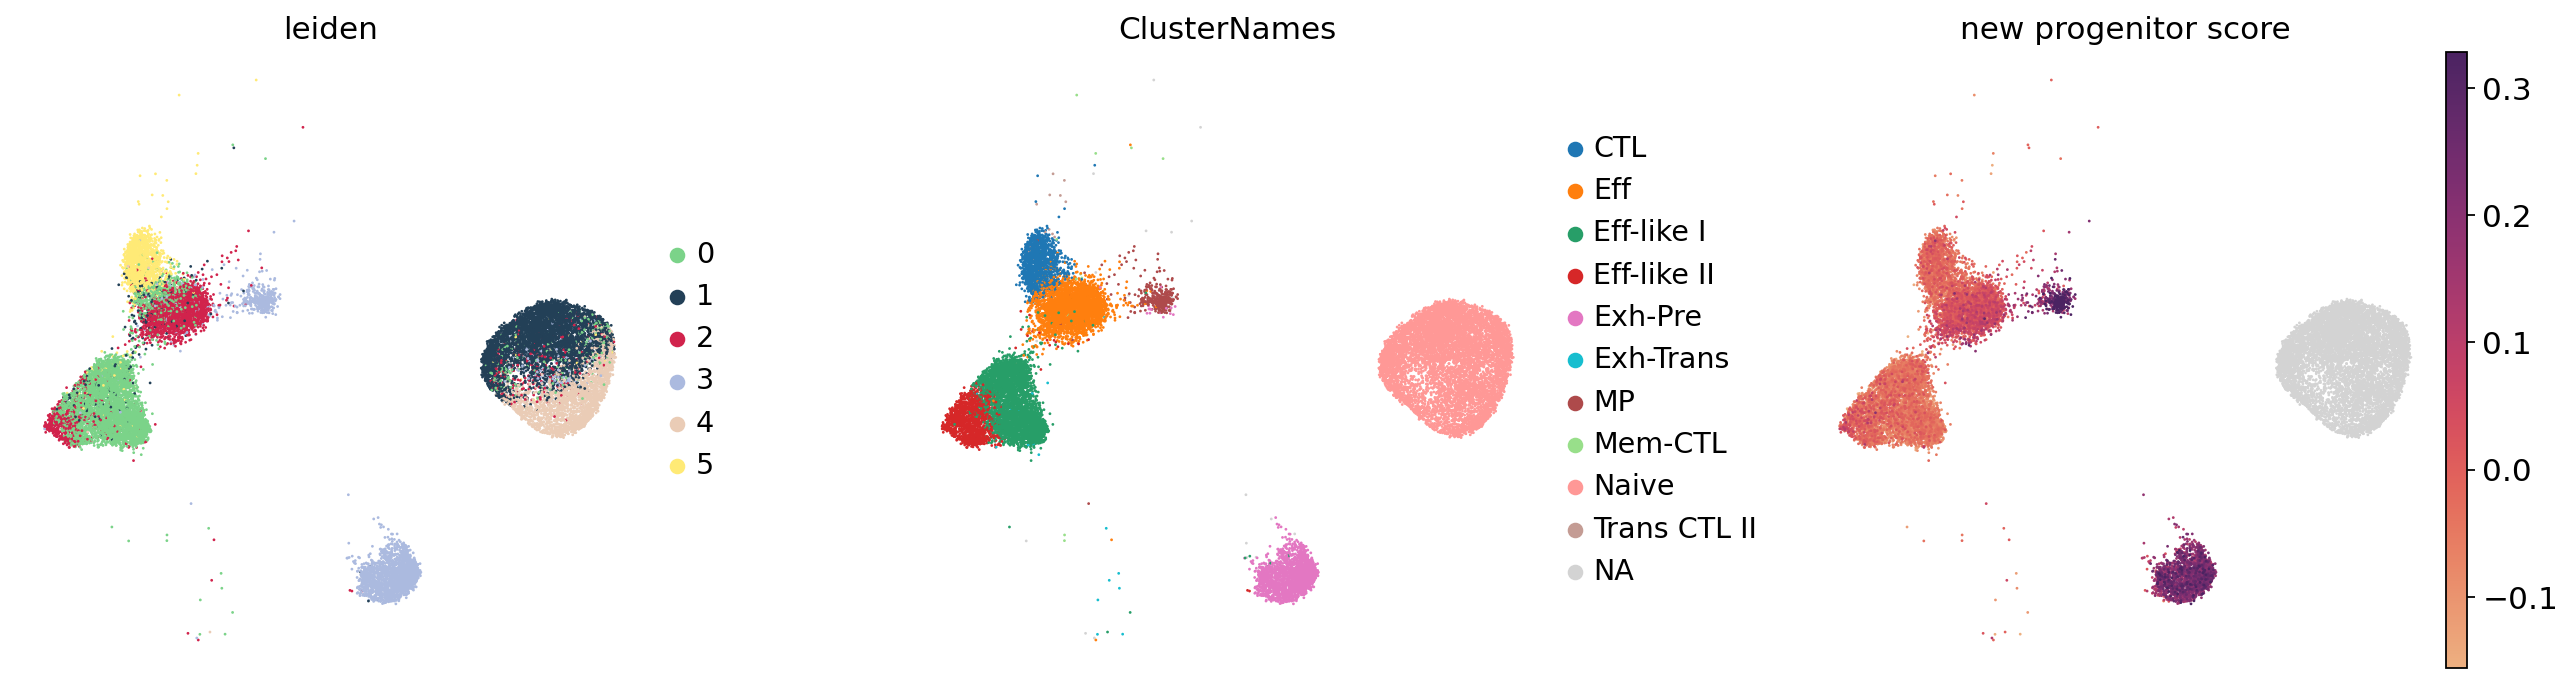

In [124]:
sc.pl.umap(wherry, color = ["leiden", "ClusterNames", "new progenitor score"], vmin = "p1", vmax = "p99", 
           cmap = "flare", wspace = 0.3, groups = ['CTL', 'Eff', 'Eff-like I', 'Eff-like II', 'Exh-Pre',
                  'Exh-Trans', 'MP', 'Mem-CTL', 'Naive', 'Trans CTL II'] + ["0", "1", "2", "3", "4", "5"],
          save = "_wherry.pdf", frameon=False)

In [125]:
wherry.obs.loc[(wherry.obs["leiden"] == "3") & (wherry.obs["ClusterNames"] == "Exh-Pre"), 
               "prog status"] = "prog in both"
wherry.obs.loc[(wherry.obs["leiden"] == "3") & (wherry.obs["ClusterNames"] == "MP"), 
               "prog status"] = "prog in mine, MP in wherry"
wherry.obs.loc[(wherry.obs["leiden"] == "3") & (~wherry.obs["ClusterNames"].isin(["Exh-Pre", "MP"])), 
               "prog status"] = "prog in mine"
wherry.obs.loc[(wherry.obs["leiden"] != "3") & (wherry.obs["ClusterNames"] == "Exh-Pre"),
               "prog status"] = "prog in theirs"
wherry.obs.loc[(wherry.obs["leiden"] != "3") & (wherry.obs["ClusterNames"] == "MP"),
               "prog status"] = "MP in theirs"

In [126]:
wherry.obs.groupby("prog status").count()

,index,n_genes_by_counts,total_counts,high_counts,sample,leiden,cellBarcode,sampleID,ClusterNames,ClusterIDs,...,progenitor score,new progenitor score,Cd8 naive arch,Cd8 mem arch,Cd4 Tfh arch,Cd8 dys arch,T cell activation arch,Cd8 eff arch,Cd4 Treg arch,Cd4 naive-mem arch
prog status,,,,,,,,,,,,,,,,,,,,,
MP in theirs,27,27,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
prog in both,1821,1821,1821,1821,1821,1821,1821,1821,1821,1821,...,1821,1821,1821,1821,1821,1821,1821,1821,1821,1821
prog in mine,271,271,271,271,271,271,271,271,265,265,...,0,141,271,271,271,271,271,271,271,271
"prog in mine, MP in wherry",343,343,343,343,343,343,343,343,343,343,...,343,343,343,343,343,343,343,343,343,343
prog in theirs,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4


## panel G

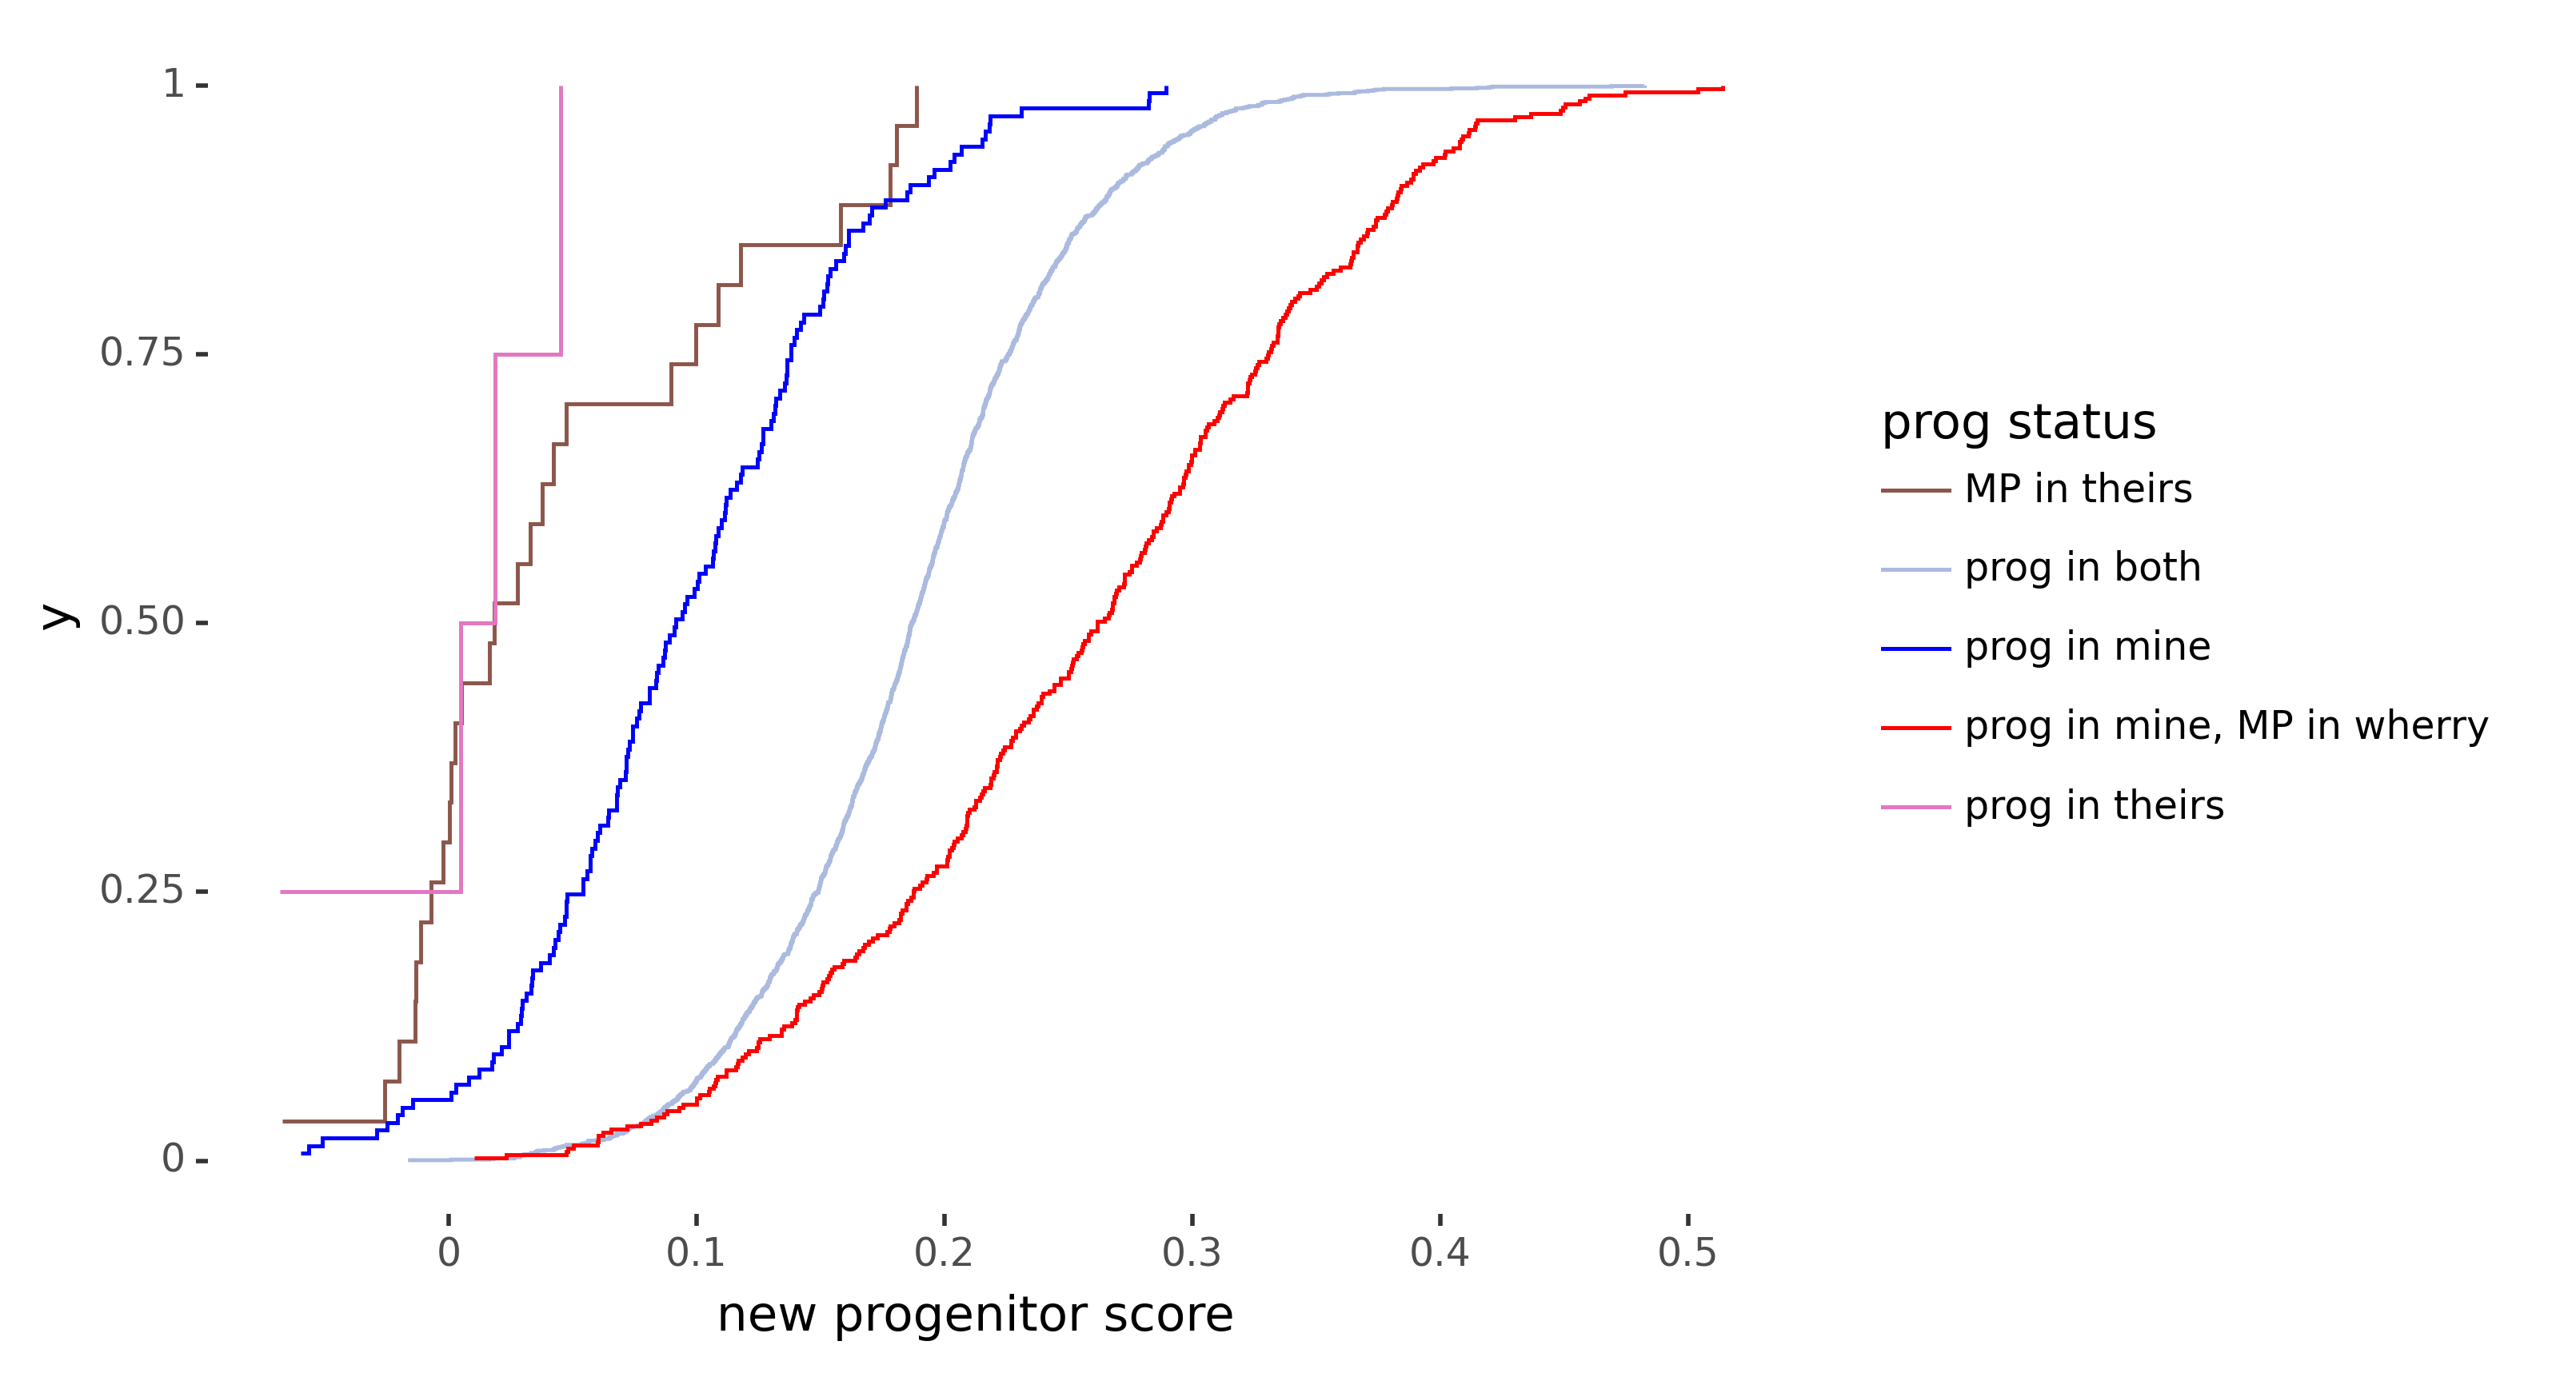

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: fig2_plots/wherry_cdf_prog_score.pdf


In [127]:
w_cdf = ggplot(wherry.obs[["new progenitor score", "prog status"]].dropna(), aes(
    x="new progenitor score", color = "prog status")) + stat_ecdf() + theme_tufte() + theme(dpi = 200) + \
scale_color_manual({"prog in both": "#abbadf", "prog in mine, MP in wherry":  "red", "prog in mine": "blue",
                    "prog in theirs": satpathy.uns["annotation_colors"][6], "MP in theirs": "#8c564b"})
print(w_cdf)
ggsave(w_cdf, "fig2_plots/wherry_cdf_prog_score.pdf", dpi = 300)

In [128]:
def test_annot(a, annot_string = "annotation", ad = wherry, dist_key = "distances"):
    print(a)
    n_cells = np.sum(ad.obs[annot_string] == a)
    sums = np.array(ad[ad.obs[annot_string] == a].obsp[dist_key].sum(
        1)).flatten()
    test_n = np.array([ad[ad.obs[annot_string] == a].obsp[dist_key][i, :].nnz for i in range(n_cells)])
    return {"annot": a, "distances": sums/test_n, "n neighbors": test_n}


In [129]:
wherry_annotation_distances = pd.concat([pd.concat([pd.DataFrame(test_annot(
    a, "ClusterNames", ad = wherry)) for a in wherry[~wherry.obs["ClusterNames"].isna()].obs[
    "ClusterNames"].unique()]).assign(version = "theirs"), pd.concat([pd.DataFrame(test_annot(
    a, "leiden", ad = wherry)) for a in wherry.obs["leiden"].unique()]).assign(version = "mine")])

Eff


/tmp/ipykernel_866987/1947791167.py:7: RuntimeWarning: invalid value encountered in true_divide


CTL
MP
Eff-like I
Eff-like II
Mem-CTL
Trans Mem
Exh-Pre
Exh-KLR
Exh-Int
Trans CTL II
Mem
Trans CTL I
Exh-Trans
Exh-Term
Naive
2
5
1
0
3
4


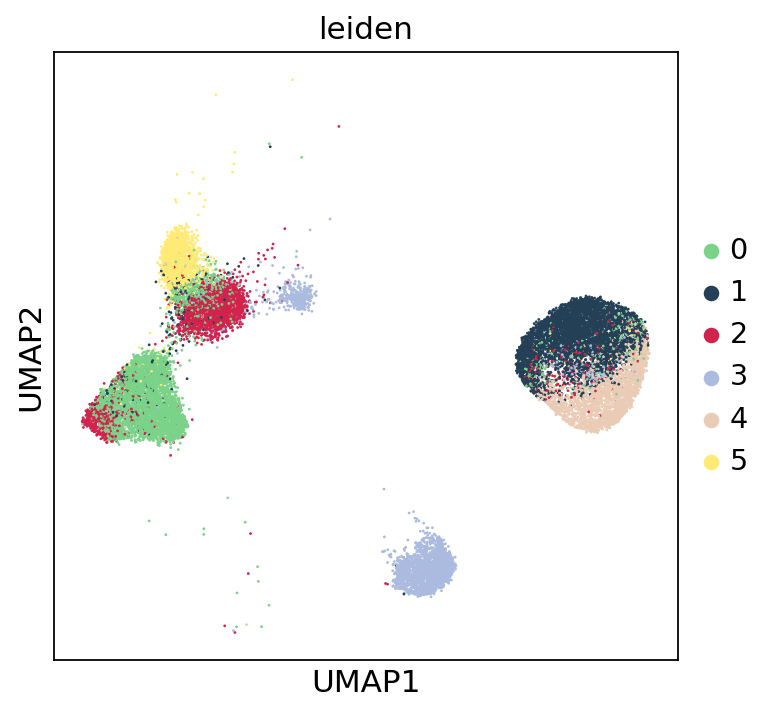

In [130]:
sc.pl.umap(wherry, color = ["leiden"])

In [132]:
wherry_prog_distances = wherry_annotation_distances[(wherry_annotation_distances["annot"].isin([
    "Exh-Pre", "MP", "3"])) & (wherry_annotation_distances["n neighbors"] > 0)]
wherry_prog_distances.loc[wherry_prog_distances["annot"] == "Exh-Pre", "version"] = "their progenitors"
wherry_prog_distances.loc[wherry_prog_distances["annot"] == "MP", "version"] = "their MPs"

## Panel H

In [134]:
wherry.uns["neighbors"]

OverloadedDict, wrapping:
	{'connectivities_key': 'connectivities', 'distances_key': 'distances', 'params': {'method': 'umap', 'metric': 'cosine', 'n_neighbors': 30, 'n_pcs': 40, 'random_state': 0, 'use_rep': 'X_pca'}}
With overloaded keys:
	['connectivities', 'distances'].

In [153]:
wherry_prog_distances["n neighbors"].min()

1

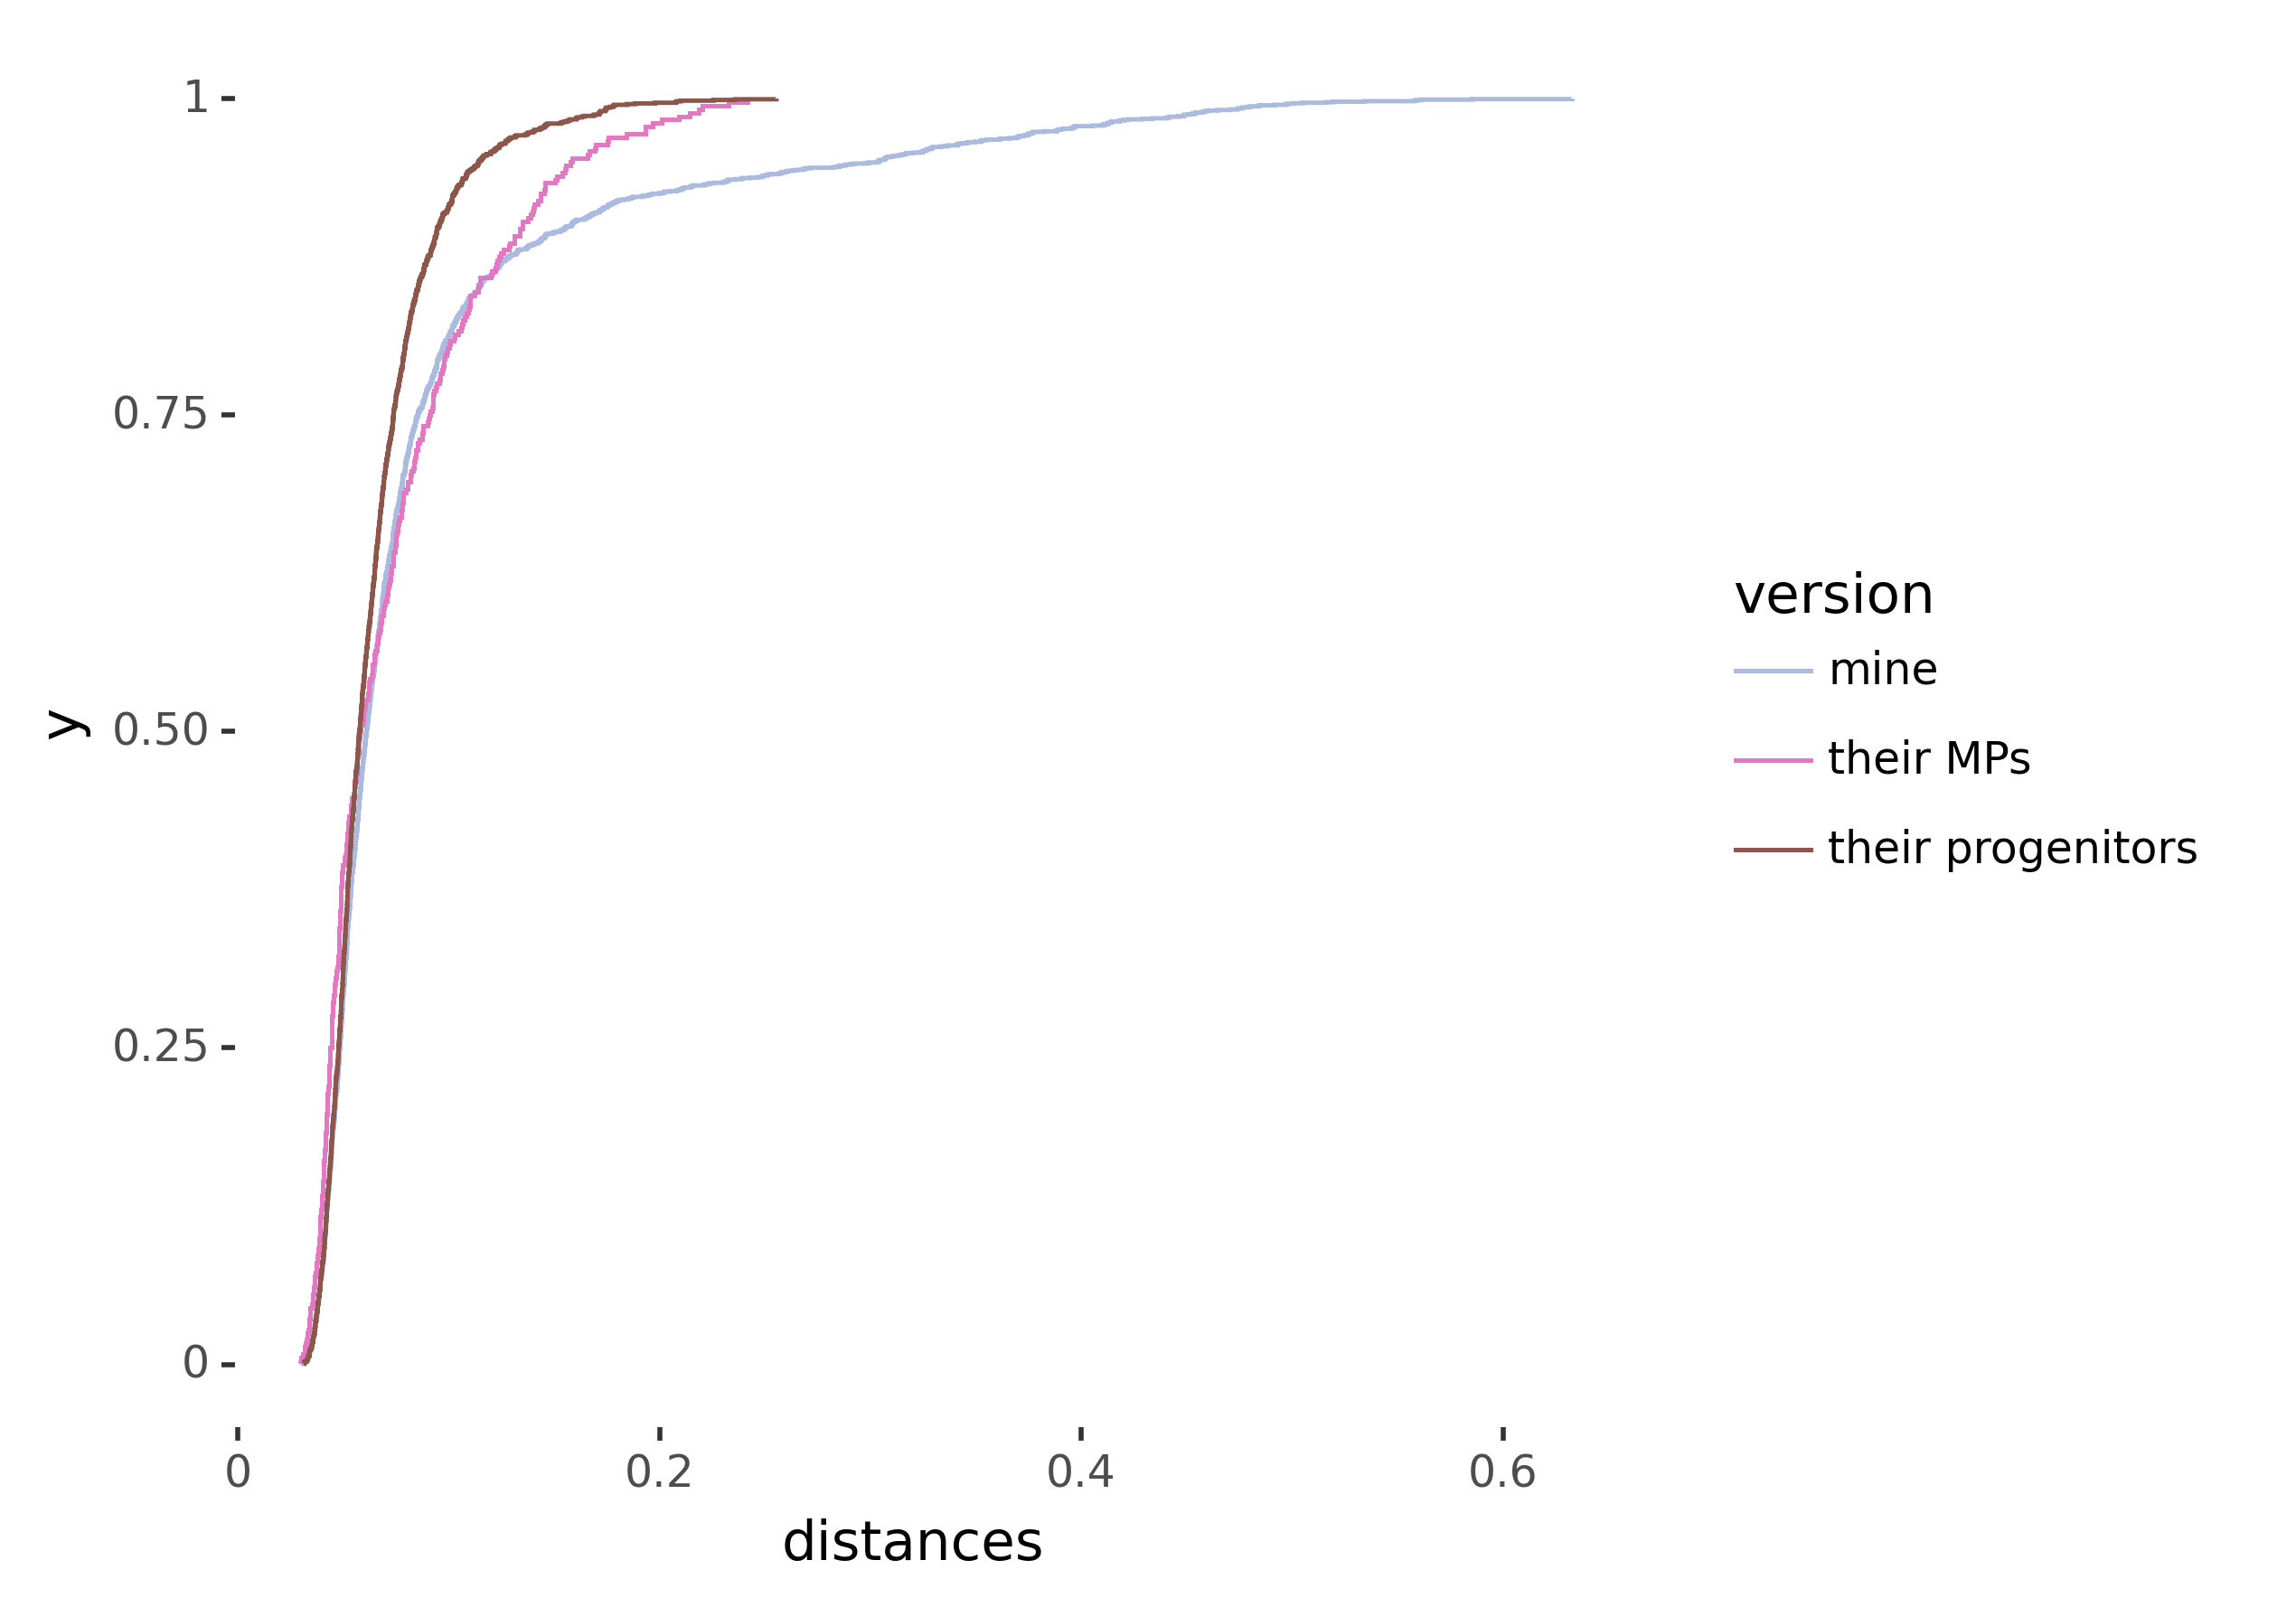

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 5 x 5 in image.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: fig2_plots/supp_prog_neighbors_cdf_wherry.pdf


In [154]:
prog_dist = ggplot(wherry_prog_distances, aes(x="distances", color = "version")) + stat_ecdf() + theme_tufte() + \
theme(dpi = 200, figure_size = (5, 5)) + scale_color_manual({"their progenitors": '#8c564b', "mine": "#abbadf",
                                                             "their MPs": "#e377c2"}) 
print(prog_dist)
ggsave(prog_dist, "fig2_plots/supp_prog_neighbors_cdf_wherry.pdf", dpi = 300)


In [138]:
wherry.obs["ClusterNames"] = wherry.obs["ClusterNames"].astype(str)
wherry.obs.loc[wherry.obs["ClusterNames"].isna(), "ClusterNames"] = "nan"

In [140]:
wherry_annot_silhouettes = silhouette_samples(np.array(their_embedding.loc[wherry.obs_names]), 
                                              labels = wherry.obs["ClusterNames"], metric = "cosine")

In [142]:
wherry_leiden_silhouettes = silhouette_samples(np.array(their_embedding.loc[wherry.obs_names]), labels = 
                                               wherry.obs["leiden"], metric = "cosine")

In [143]:
my_wherry_annot_silhouettes = silhouette_samples(wherry.obsm["X_pca"][:, 0:50], labels = wherry.obs[
    "ClusterNames"], metric = "cosine")

In [144]:
my_wherry_leiden_silhouettes = silhouette_samples(wherry.obsm["X_pca"][:, 0:50], labels = wherry.obs[
    "leiden"], metric = "cosine")

In [145]:
wherry_sil = pd.concat([pd.DataFrame({"silhouette": wherry_annot_silhouettes, "cluster": wherry.obs[
    "ClusterNames"], "cell_name": wherry.obs_names}).merge(pd.DataFrame({
    "silhouette": my_wherry_annot_silhouettes, "labeling": "annot", "cluster": wherry.obs[
        "leiden"], "cell_name": wherry.obs_names}), on = ["cell"], suffixes = [".theirs", ".mine"]).assign(
    labeling =  "annot"), pd.DataFrame({"silhouette": wherry_leiden_silhouettes, "cluster": wherry.obs[
    "ClusterNames"], "cell_name": wherry.obs_names}).merge(pd.DataFrame({
    "silhouette": my_wherry_leiden_silhouettes, "cluster": wherry.obs["leiden"], "cell_name": wherry.obs_names}
), on = "cell", suffixes = [".theirs", ".mine"]).assign(labeling = "leiden")])

## panel I

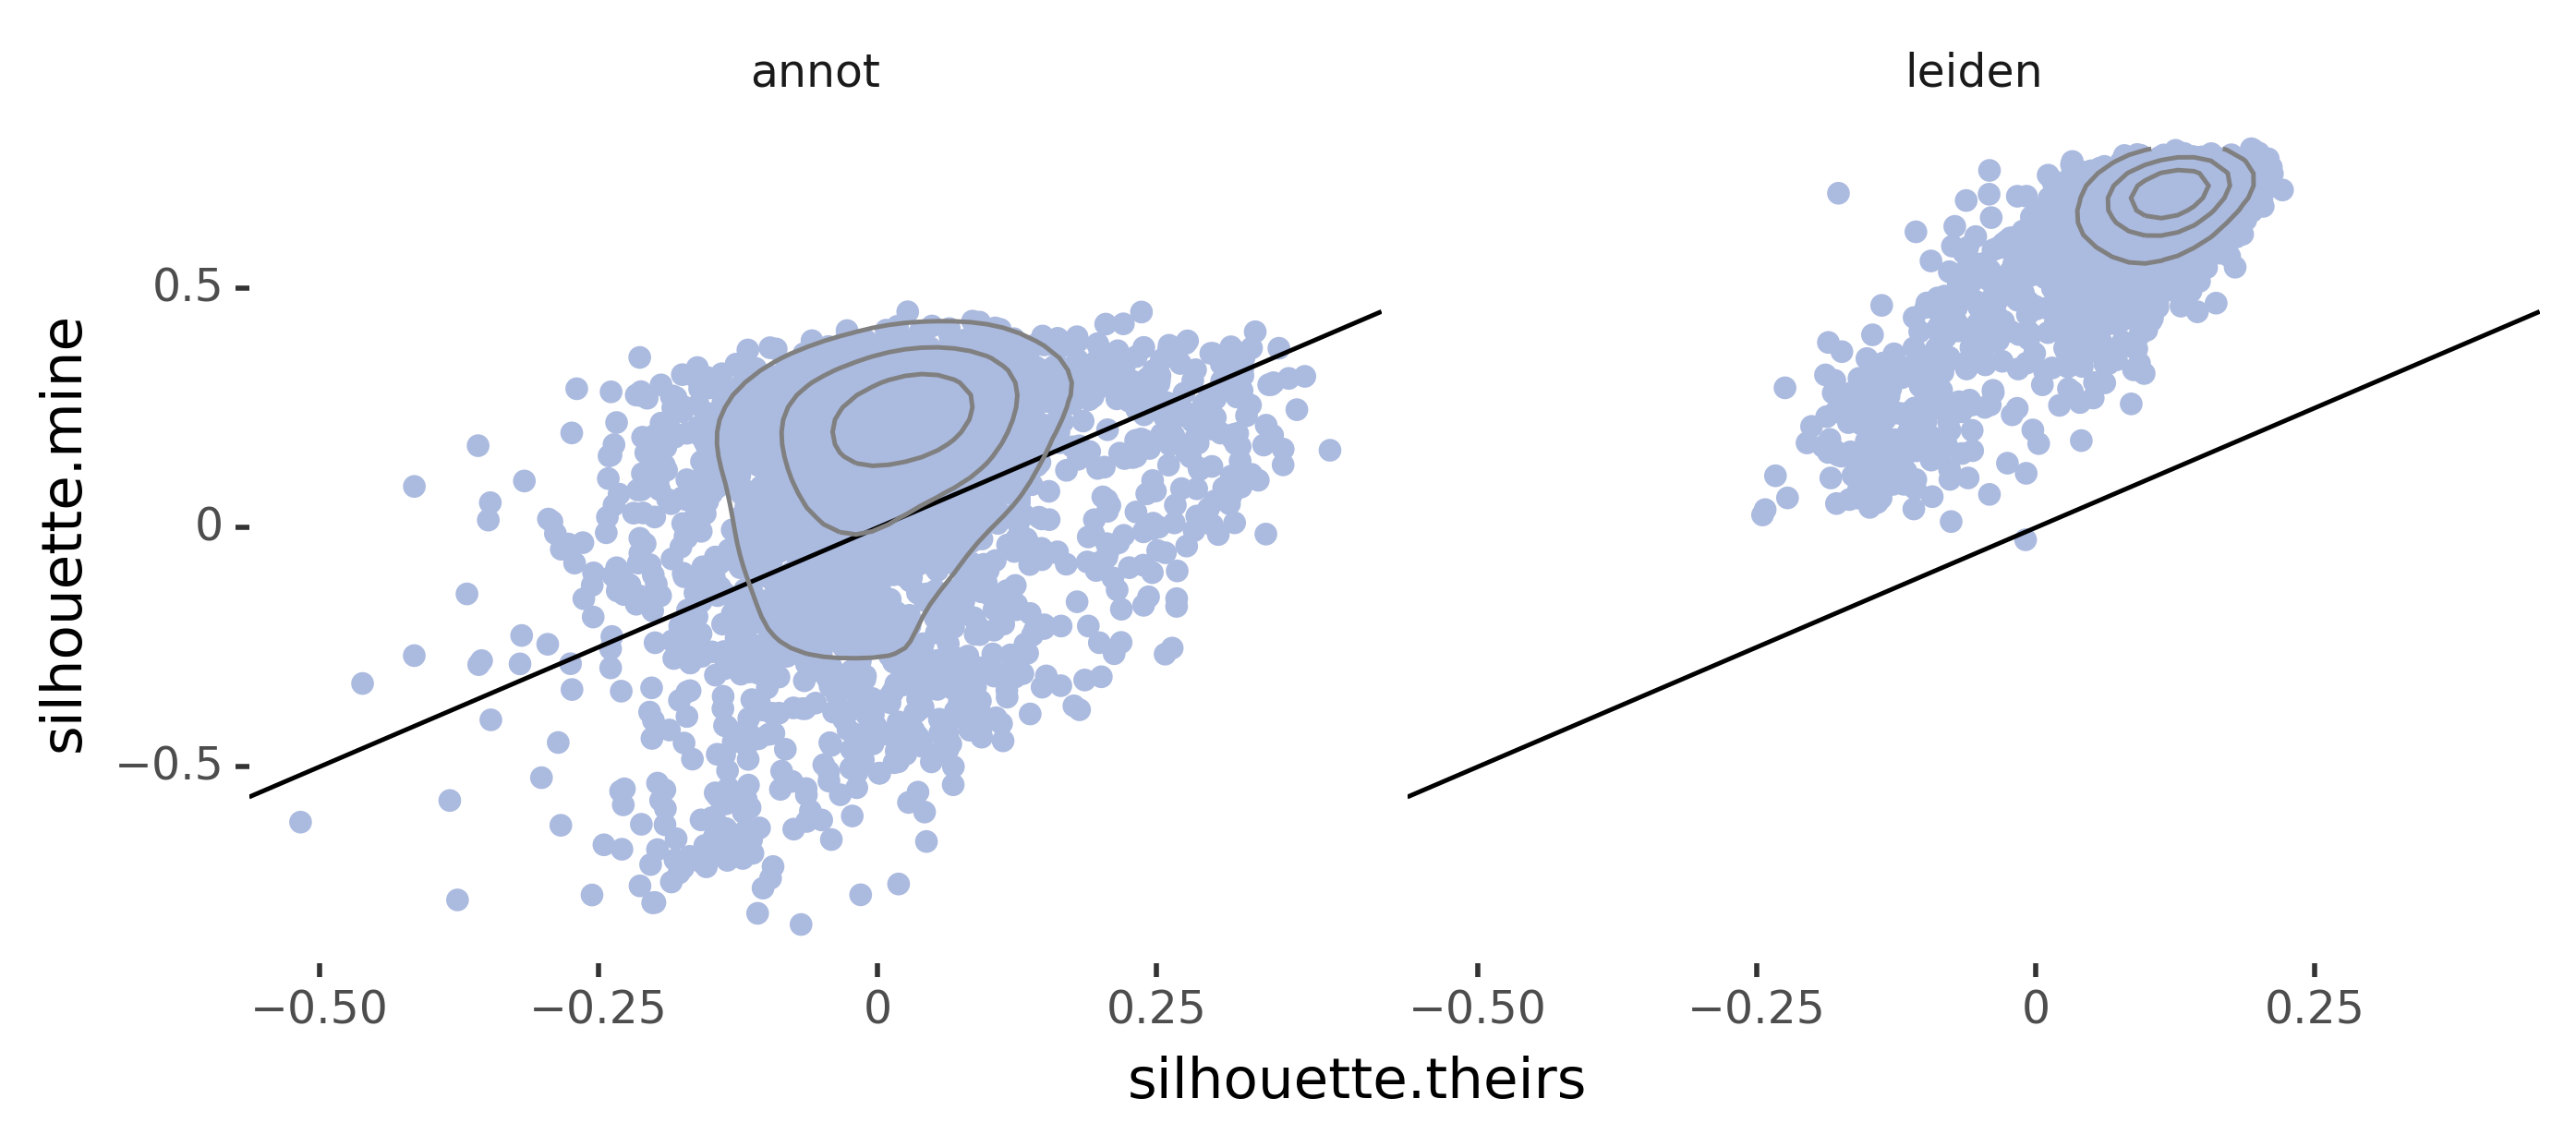

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 8 x 3 in image.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: fig2_plots/wherry_sil_plot.pdf


In [146]:
wherry_sil_plt = ggplot(wherry_sil[wherry_sil["cluster.mine"] == "3"], aes(
    x="silhouette.theirs", y = "silhouette.mine")) + geom_point(color = "#abbadf") + theme_tufte() + theme(
    dpi = 200, figure_size = (8, 3)) + facet_wrap("~ labeling") + geom_abline(slope = 1, intercept = 0) + \
geom_density_2d(color = "gray")
print(wherry_sil_plt)
ggsave(wherry_sil_plt, "fig2_plots/wherry_sil_plot.pdf", dpi = 200)

## panel J

Index(['Cd8 naive arch', 'Cd8 mem arch', 'Cd4 Tfh arch', 'Cd8 dys arch',
       'T cell activation arch', 'Cd8 eff arch', 'Cd4 Treg arch',
       'Cd4 naive-mem arch'],
      dtype='object')

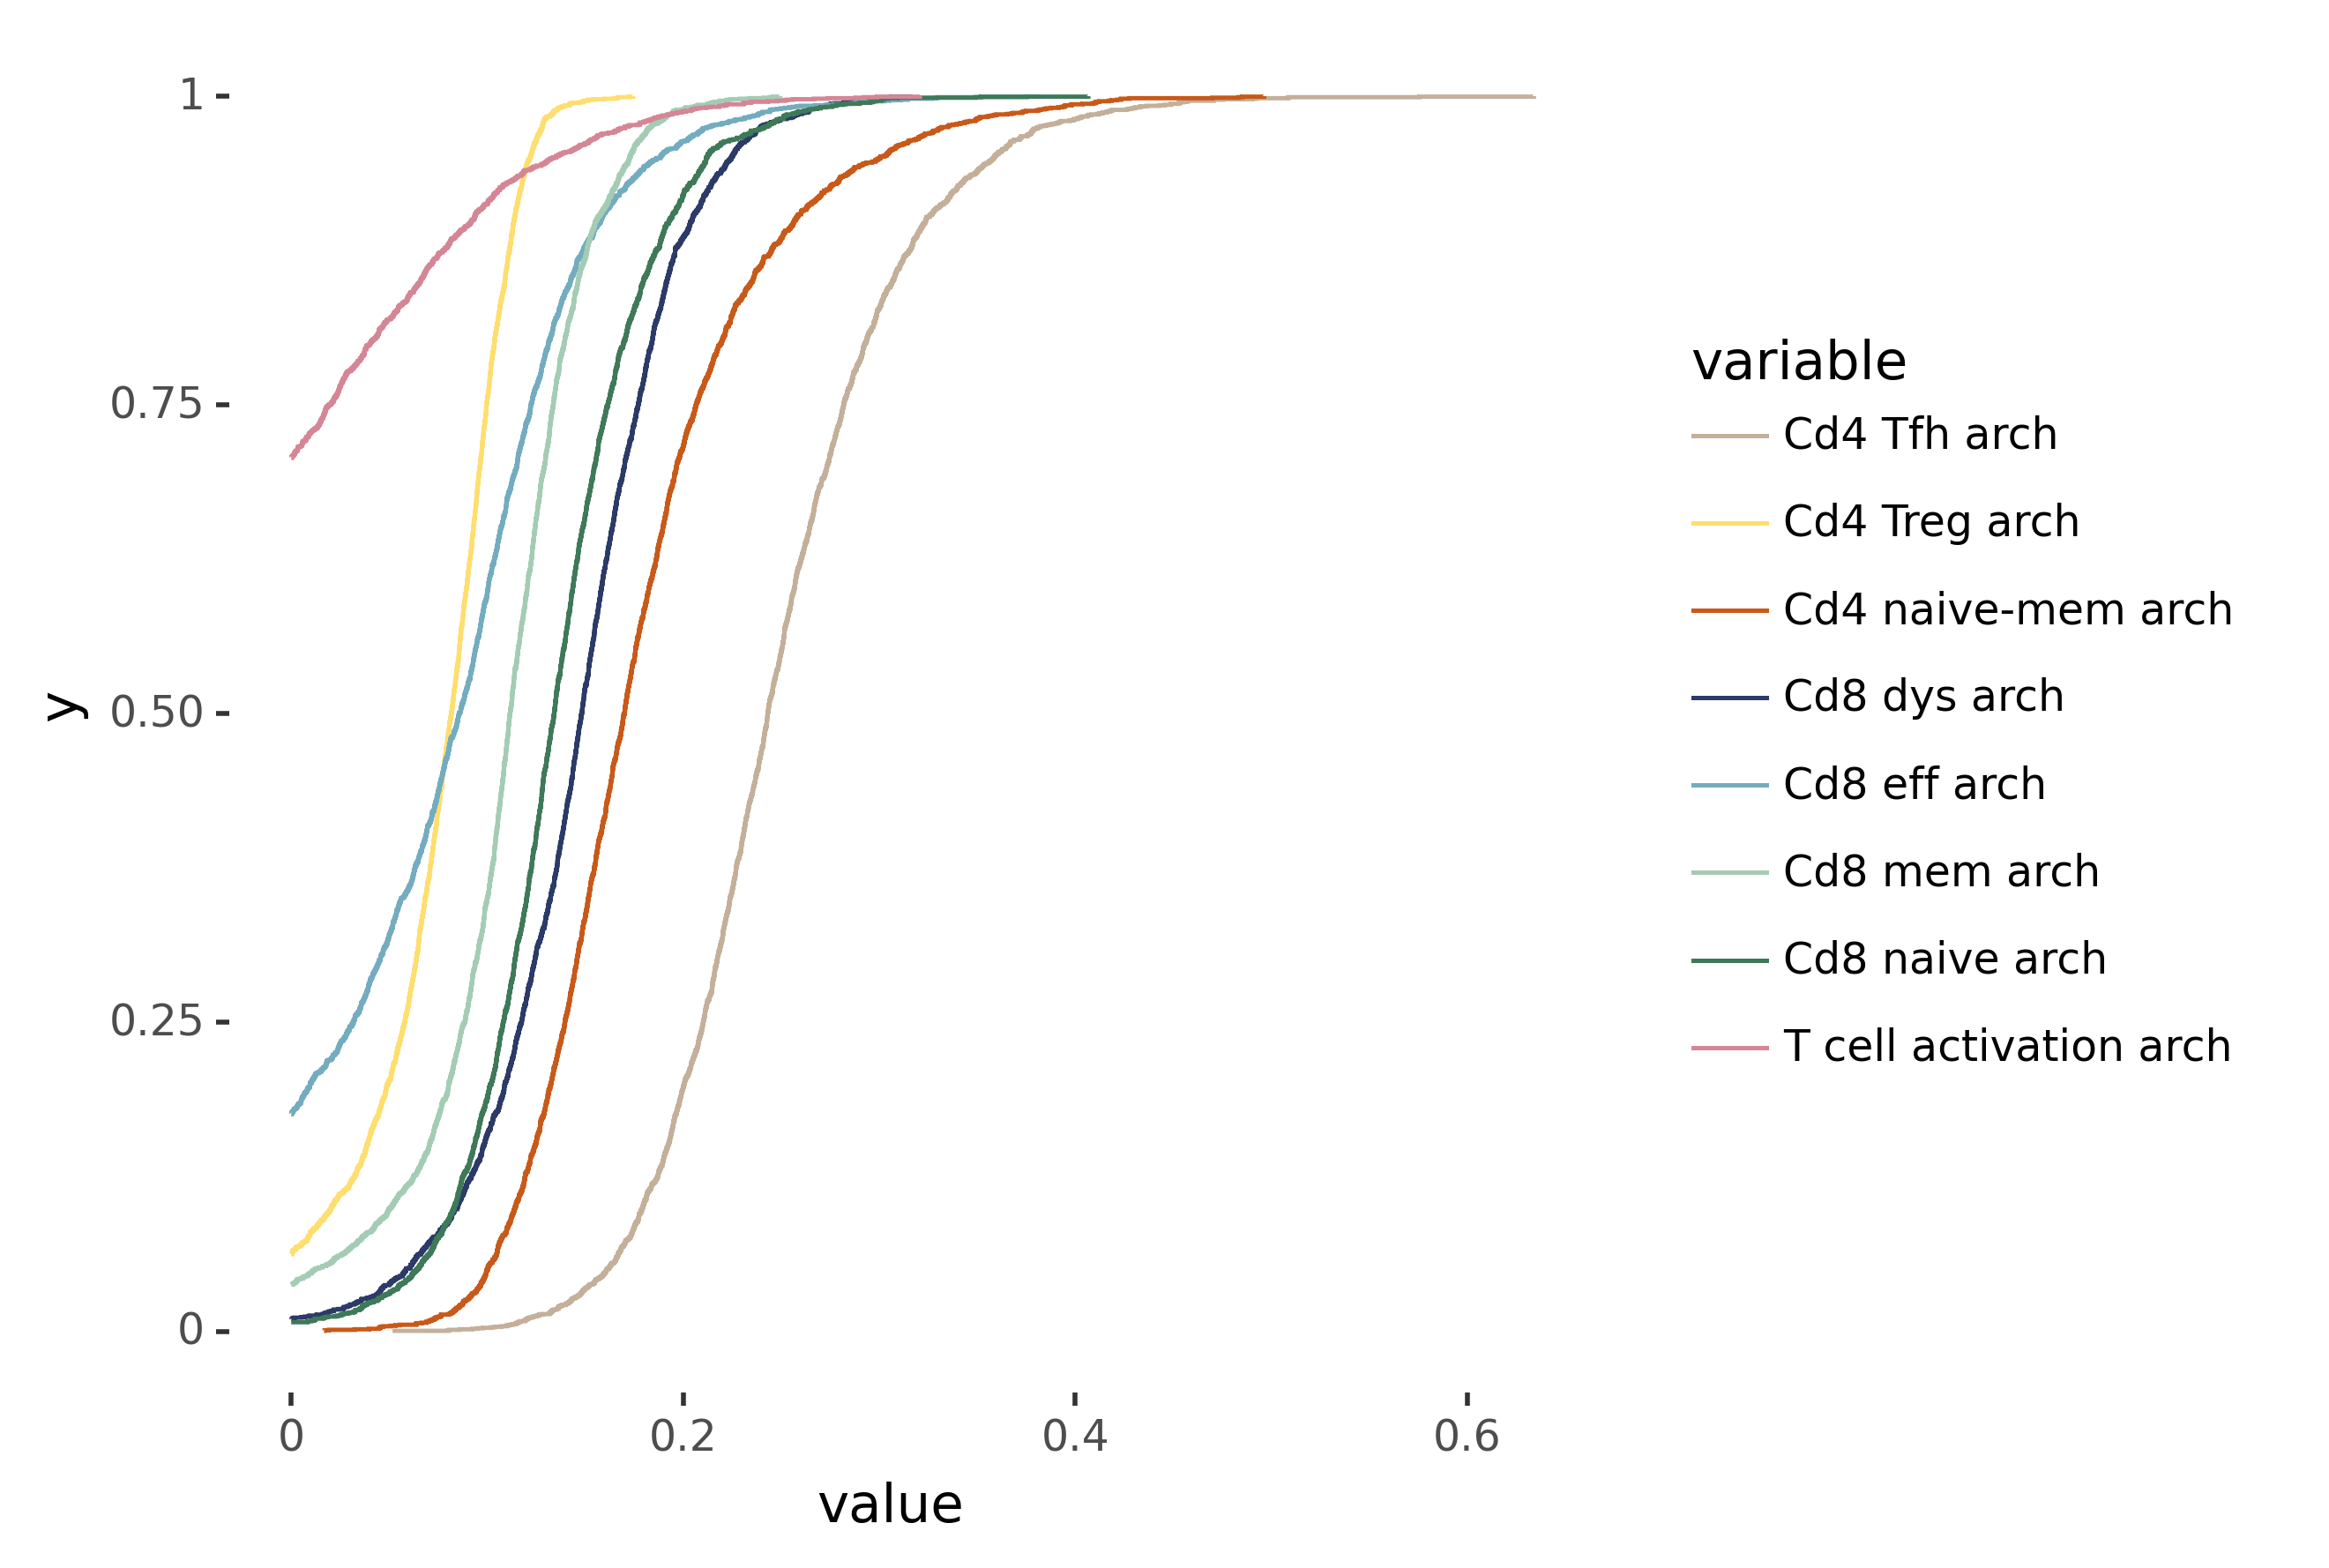

<ggplot: (8756023079512)>

In [160]:
wherry_arch_scores = ggplot(wherry[wherry.obs["leiden"] == "3"].obs.melt(value_vars = list(
    wherry.obs.columns[wherry.obs.columns.str.endswith("arch")])), aes(x="value", color = "variable")) + \
stat_ecdf() + theme_tufte() + theme(dpi = 200, figure_size = (5, 5)) + scale_color_manual(arch_colors)
wherry_arch_scores

In [161]:
ggsave(wherry_arch_scores, "fig2_plots/supp_wherry_prog_arch_scores.pdf", dpi = 300)

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 5 x 5 in image.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: fig2_plots/supp_wherry_prog_arch_scores.pdf


In [162]:
wherry.obsm["X_pca_50"] = wherry.obsm["X_pca"].copy()[:, 0:50]
wherry.obsm["X_pca_50"].shape

(19404, 50)

In [164]:
wherry.obsm["X_pca_theirs"] = np.array(their_embedding.loc[wherry.obs_names])
wherry.obsm["X_pca_theirs"].shape

(19404, 50)

In [165]:
sc.pp.neighbors(wherry, key_added = "my_50pcs_k20", metric = "cosine", use_rep = "X_pca_50", n_neighbors = 20)
sc.pp.neighbors(wherry, key_added = "their_50lsi_k20", metric = "cosine", use_rep = "X_pca_theirs", 
                n_neighbors = 20)

In [167]:
def test_nonannot(a, annot_string = "annotation", ad = wherry, dist_key = "distances"):
    print(a)
    n_cells = np.sum(ad.obs[annot_string] == a)
    noncluster_means = np.array(ad.obsp[dist_key][np.where(ad.obs[annot_string] == a)[
      0],:][:, np.where(ad.obs[annot_string] != a)[0]].sum(axis = 1)).flatten()
    test_n =  np.array([ad.obsp[dist_key][np.where(ad.obs[annot_string] == a)[
        0],:][:, np.where(ad.obs[annot_string] != a)[0]][i, :].nnz for i in range(n_cells)])
    
    return {"annot": a, "distances": noncluster_means/test_n, "n neighbors": test_n}

In [168]:
new_wherry_nonannotation_distances = pd.concat([pd.concat([pd.concat([pd.DataFrame(test_nonannot(
    a, "ClusterNames", ad = wherry, dist_key = dist)) for a in wherry[~wherry.obs["ClusterNames"].isna()].obs[
    "ClusterNames"].unique()]).assign(version = "theirs"), pd.concat([pd.DataFrame(test_nonannot(
    a, "leiden", ad = wherry, dist_key = dist)) for a in wherry.obs["leiden"].unique()]).assign(
    version = "mine")]).assign(graph = dist.split("_")[0]) for dist in ["my_50pcs_k20_distances", 
                                                                        "their_50lsi_k20_distances"]])

Eff


/tmp/ipykernel_866987/3293764294.py:9: RuntimeWarning: invalid value encountered in true_divide


CTL
MP
Eff-like I
Eff-like II
Mem-CTL
Trans Mem
Exh-Pre
Exh-KLR
Exh-Int
Trans CTL II
Mem
Trans CTL I
nan
Exh-Trans
Exh-Term
Naive
2


/tmp/ipykernel_866987/3293764294.py:9: RuntimeWarning: invalid value encountered in true_divide


5
1
0
3
4
Eff


/tmp/ipykernel_866987/3293764294.py:9: RuntimeWarning: invalid value encountered in true_divide


CTL
MP
Eff-like I
Eff-like II
Mem-CTL
Trans Mem
Exh-Pre
Exh-KLR
Exh-Int
Trans CTL II
Mem
Trans CTL I
nan
Exh-Trans
Exh-Term
Naive
2


/tmp/ipykernel_866987/3293764294.py:9: RuntimeWarning: invalid value encountered in true_divide


5
1
0
3
4


In [169]:
new_wherry_annotation_distances = pd.concat([pd.concat([pd.concat([pd.DataFrame(test_annot(
    a, "ClusterNames", ad = wherry, dist_key = dist)) for a in wherry[~wherry.obs["ClusterNames"].isna()].obs[
    "ClusterNames"].unique()]).assign(version = "theirs"), pd.concat([pd.DataFrame(test_annot(
    a, "leiden", ad = wherry, dist_key = dist)) for a in wherry.obs["leiden"].unique()]).assign(
    version = "mine")]).assign(graph = dist.split("_")[0]) for dist in [
    "my_50pcs_k20_distances", "their_50lsi_k20_distances"]])

Eff


/tmp/ipykernel_866987/1947791167.py:7: RuntimeWarning: invalid value encountered in true_divide


CTL
MP
Eff-like I
Eff-like II
Mem-CTL
Trans Mem
Exh-Pre
Exh-KLR
Exh-Int
Trans CTL II
Mem
Trans CTL I
nan
Exh-Trans
Exh-Term
Naive
2
5
1


/tmp/ipykernel_866987/1947791167.py:7: RuntimeWarning: invalid value encountered in true_divide


0
3
4
Eff


/tmp/ipykernel_866987/1947791167.py:7: RuntimeWarning: invalid value encountered in true_divide


CTL
MP
Eff-like I
Eff-like II
Mem-CTL
Trans Mem
Exh-Pre
Exh-KLR
Exh-Int
Trans CTL II
Mem
Trans CTL I
nan
Exh-Trans
Exh-Term
Naive
2


/tmp/ipykernel_866987/1947791167.py:7: RuntimeWarning: invalid value encountered in true_divide


5
1
0
3
4


In [170]:
test_dist = new_wherry_nonannotation_distances[new_wherry_nonannotation_distances["n neighbors"] > 0].groupby([
    "annot", "version", "graph"]).median()[["distances"]].merge(
new_wherry_annotation_distances[new_wherry_annotation_distances["n neighbors"] > 0].groupby([
    "annot", "version", "graph"]).median()[["distances"]], left_index = True, right_index = True, suffixes = [
    ".noncluster", ".cluster"])
test_dist

distances.noncluster  distances.cluster
annot        version graph                                         
0            mine    my                 0.191830           0.120472
                     their              0.391078           0.384656
1            mine    my                 0.319715           0.272799
                     their              0.314296           0.307991
2            mine    my                 0.214740           0.194073
                     their              0.397237           0.391366
3            mine    my                 0.294681           0.069915
                     their              0.411458           0.373643
4            mine    my                 0.370260           0.254553
                     their              0.306756           0.285713
5            mine    my                 0.176893           0.116911
                     their              0.388005           0.361169
CTL          theirs  my                 0.140536           0.114123
                     their              0.393038           0.361201
Eff          theirs  my                 0.197353           0.195888
                     their              0.416352           0.400399
Eff-like I   theirs  my                 0.128367           0.108004
                     their              0.403481           0.390659
Eff-like II  theirs  my                 0.136835           0.132645
                     their              0.377504           0.351353
Exh-Pre      theirs  my                 0.076517           0.066378
                     their              0.408727           0.371960
Exh-Trans    theirs  my                 0.176640           0.473528
                     their              0.464520           0.597951
MP           theirs  my                 0.082378           0.065235
                     their              0.420526           0.384485
Mem-CTL      theirs  my                 0.194678           0.163222
                     their              0.360140           0.278007
Naive        theirs  my                 0.342297           0.282247
                     their              0.298471           0.301123
Trans CTL II theirs  my                 0.121006           0.136279
                     their              0.419054           0.403105

In [171]:
test_dist["diff in medians"] = test_dist["distances.cluster"] - test_dist["distances.noncluster"]

## panel K

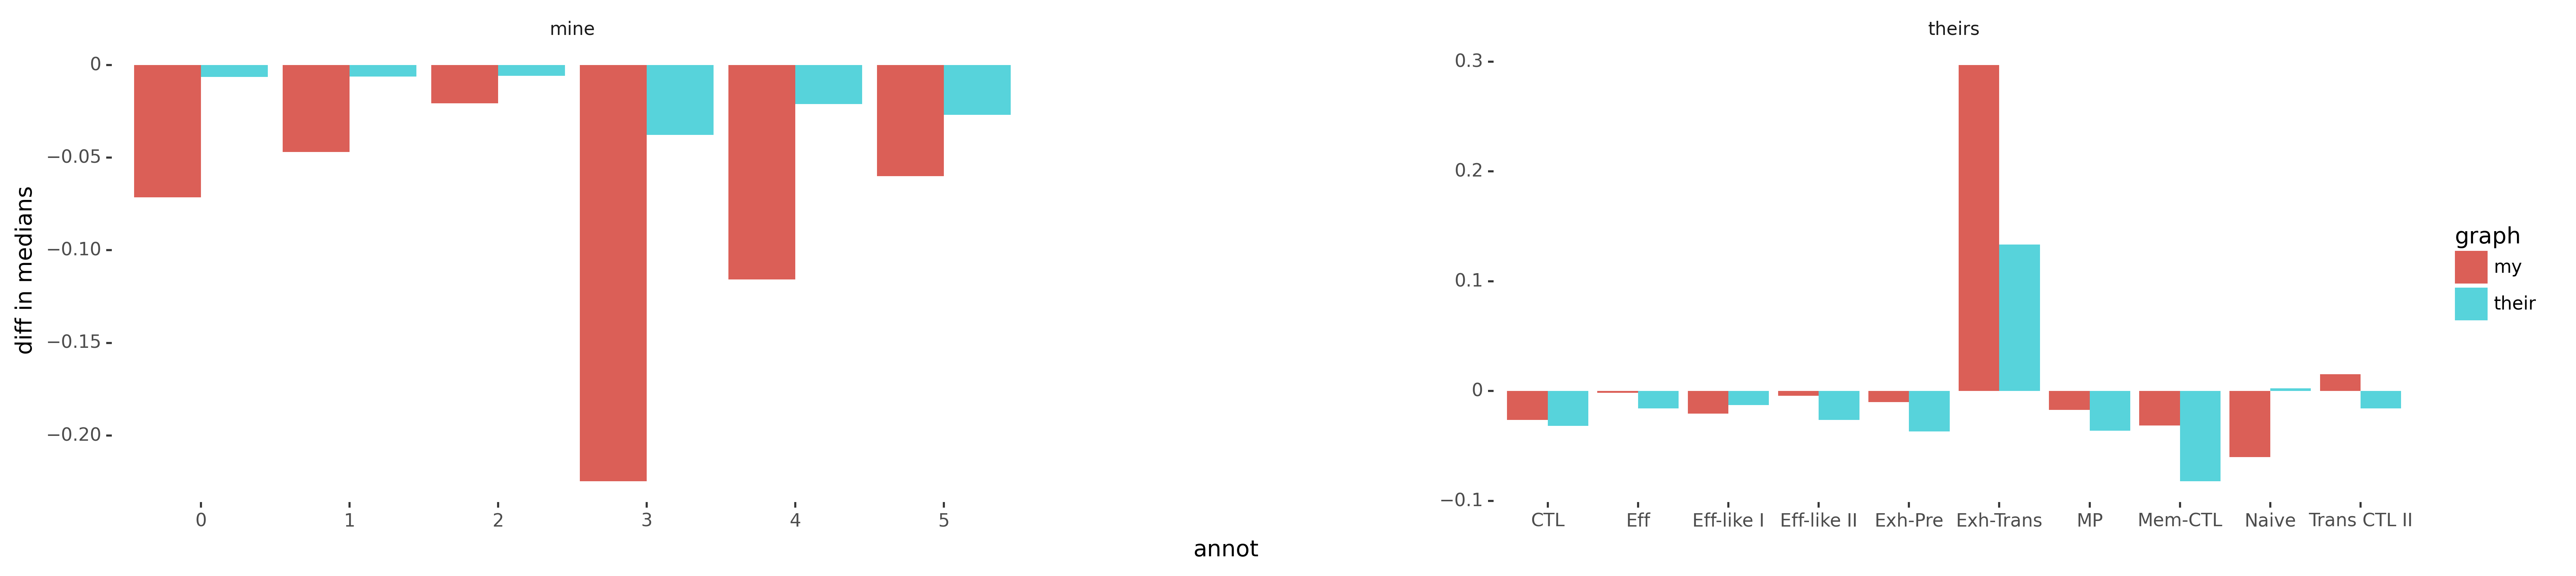

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 20 x 4 in image.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: fig2_plots/supp_comp_graphs.bar.pdf


In [172]:
comp_dist_plt = ggplot(test_dist.reset_index(), aes(x="annot", fill = "graph", y = "diff in medians")) + geom_bar(
stat = "identity", position = "dodge") + theme_tufte() + theme(subplots_adjust = {'wspace': 0.5}, figure_size = (
    20, 4), dpi = 200) + facet_wrap("~ version", scales = "free")
print(comp_dist_plt)
ggsave(comp_dist_plt, "fig2_plots/supp_comp_graphs.bar.pdf")

## fraction Satpathy progenitors in our progenitor cluster

In [4]:
np.sum((satpathy.obs["annotation"] == "Progenitor") & (satpathy.obs["leiden"] == "4"))/np.sum(
    satpathy.obs["annotation"] == "Progenitor")

0.863905325443787

In [7]:
np.sum((wherry.obs["ClusterNames"] == "Exh-Pre") & (wherry.obs["leiden"] == "3"))/np.sum(
    wherry.obs["ClusterNames"] == "Exh-Pre")

0.9978082191780822

In [9]:
np.sum(((wherry.obs["ClusterNames"] == "Exh-Pre") | (wherry.obs["ClusterNames"] == "MP")) & (wherry.obs[
    "leiden"] == "3"))/np.sum((wherry.obs["ClusterNames"] == "Exh-Pre") | (wherry.obs["ClusterNames"] == "MP"))
                              

0.985876993166287

In [11]:
np.sum((wherry.obs["ClusterNames"] == "MP") & (wherry.obs[
    "leiden"] == "3"))/np.sum(wherry.obs["ClusterNames"] == "MP")
                              

0.927027027027027